# p05_aqr: テーマETFローテーション戦略のPPO拡張（Notebook完結）

- 参照戦略（S2-L / S2-R / EQW）を再現しつつ、PPO（factor/etf行動）を追加
- データリーク防止: 特徴量は決定時点tまで、適用はt+1
- 固定分割評価: applied return period 기준 `2021-01-01` 以降をテスト

In [1]:
import warnings
warnings.filterwarnings('ignore')

import random
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import yfinance as yf
from pathlib import Path
from IPython.display import display

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
import torch

pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')


def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(42)

# Resolve project root robustly (works from project root or notebooks/ cwd)
cwd = Path.cwd()
if (cwd / 'data' / 'theme_etf.csv').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data' / 'theme_etf.csv').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd


def _convert_months_to_periods(month_value, scale):
    return max(1, int(round(float(month_value) * scale)))


def resolve_runtime_params(config):
    rebalance = str(config.get('rebalance', 'M')).upper()
    if rebalance == 'M':
        rule = 'ME'
        periods_per_year = 12
        scale = 1.0
        frequency_label = 'Monthly (EOM)'
    elif rebalance == 'W-FRI':
        rule = 'W-FRI'
        periods_per_year = 52
        scale = 52.0 / 12.0
        frequency_label = 'Weekly (W-FRI EOW)'
    else:
        raise ValueError("rebalance must be 'M' or 'W-FRI'.")

    pca_window = _convert_months_to_periods(config['pca_window_months'], scale)
    reg_window = _convert_months_to_periods(config['regression_window_months'], scale)
    min_obs = _convert_months_to_periods(config['min_obs_per_window'], scale)
    skip_periods = _convert_months_to_periods(config['factor_mom_skip_months'], scale)
    dispersion_window = _convert_months_to_periods(config['dispersion_window_months'], scale)

    lookbacks_months = [int(x) for x in config['factor_mom_lookbacks']]
    lookbacks_periods = [_convert_months_to_periods(x, scale) for x in lookbacks_months]

    # 変換後lookbackが重複する場合はweightを合算
    raw_cw = {int(k): float(v) for k, v in config['combine_weights'].items()}
    combined = {}
    for lb_month, lb_period in zip(lookbacks_months, lookbacks_periods):
        w = raw_cw.get(lb_month, 0.0)
        combined[lb_period] = combined.get(lb_period, 0.0) + w

    if sum(combined.values()) == 0:
        unique_lb = sorted(set(lookbacks_periods))
        combined = {lb: 1.0 / len(unique_lb) for lb in unique_lb}
    else:
        s = sum(combined.values())
        combined = {k: v / s for k, v in combined.items()}

    lookbacks_periods = sorted(set(lookbacks_periods))

    return {
        'rebalance': rebalance,
        'rule': rule,
        'periods_per_year': periods_per_year,
        'scale': scale,
        'frequency_label': frequency_label,
        'pca_window': pca_window,
        'reg_window': reg_window,
        'min_obs': min_obs,
        'skip_periods': skip_periods,
        'dispersion_window': dispersion_window,
        'lookbacks_periods': lookbacks_periods,
        'combine_weights_periods': combined,
        'lookback_month_to_period': dict(zip(lookbacks_months, [_convert_months_to_periods(x, scale) for x in lookbacks_months])),
    }


CONFIG = {
    # Data scope
    'start_date': '2010-07-23',
    'end_date': None,
    'tickers': [
        'AGNG','AIQ','AQWA','BITS','BKCH','BOTZ','BUG','CHPX','CLOU','CTEC','DRIV','DTCR',
        'EBIZ','FINX','GNOM','HEAL','HERO','HYDR','IPAV','KROP','LIT','MILN','PAVE','RNRG',
        'SHLD','SNSR','SOCL','ZAP'
    ],
    'rebalance': 'W-FRI',  # 'M' or 'W-FRI'
    'cost_bps': 10,
    'benchmark': 'EQW',

    # Data source
    'use_yfinance': False,     # False: use data/theme_etf.csv
    'local_csv_path': str((PROJECT_ROOT / 'data' / 'theme_etf.csv').resolve()),

    # Factor construction (monthly meaning; converted to runtime periods)
    'factor_method': 'pca',
    'pca_window_months': 60,
    'n_components': 8,
    'standardize': True,
    'min_obs_per_window': 24,

    # Factor momentum (monthly meaning; converted to runtime periods)
    'factor_mom_lookbacks': [1, 12],
    'factor_mom_skip_months': 1,
    'combine_weights': {1: 0.5, 12: 0.5},
    'factor_weighting': 'top_m',
    'top_m_factors': 3,
    'exclude_pcs': [1],

    # ETF mapping (monthly meaning; converted to runtime periods)
    'etf_mapping_modes': ['loadings', 'regression'],
    'regression_window_months': 60,

    # Portfolio constraints
    'long_only': True,
    'weight_cap': None,

    # Optional risk gates (default OFF for backward compatibility)
    'use_breadth_gate': False,
    'breadth_threshold': 0.6,
    'use_dispersion_gate': False,
    'dispersion_window_months': 60,
    'dispersion_q_high': 0.8,

    # PPO settings
    'rl': {
        'split_date': '2021-01-01',
        'action_modes': ['factor', 'etf'],
        'reward_objectives': ['differential_sharpe', 'mean_variance'],
        'reward_primary': 'compare',
        'reward_base': 'net',
        'reward_scale': 1.0,  # legacy scale (not used when stabilizer is enabled)
        'train_rebalance': 'W-FRI',
        'total_timesteps_factor': 120000,
        'total_timesteps_etf': 180000,
        'seed': 42,
        'history_len': 4,
        'include_action_history': True,
        'agent_state_fields': ['gross', 'net', 'turnover', 'drawdown'],
        'risk_estimator': {
            'type': 'ewma',
            'half_life_periods': 26,
            'eps': 1e-8,
        },
        'mean_variance': {
            'lambda': 5.0,
        },
        'differential_sharpe': {
            'eps': 1e-8,
        },
        'reward_stabilizer': {
            'standardize': True,
            'tanh_clip': True,
            'tanh_scale': 2.0,
            'eps': 1e-8,
        },
        'learning_curve': {
            'enable': True,
            'smooth_span': 20,
            'metrics': [
                'rollout/ep_rew_mean',
                'train/value_loss',
                'train/policy_gradient_loss',
                'train/entropy_loss',
            ],
            'min_points_warn': 10,
        },
        'macro': {
            'enable_vix': True,
            'source': 'local_csv',
            'vix_local_path': str((PROJECT_ROOT / 'data' / 'vix_daily.csv').resolve()),
            'date_col': 'Date',
            'close_col': 'Close',
            'zscore_window_months': 6,
        },
        'ppo_params': {
            'learning_rate': 3e-4,
            'n_steps': 256,
            'batch_size': 64,
            'n_epochs': 10,
            'gamma': 0.99,
            'gae_lambda': 0.95,
            'clip_range': 0.2,
            'ent_coef': 0.0,
            'vf_coef': 0.5,
            'max_grad_norm': 0.5,
        },
        'policy_kwargs': {
            'net_arch': [64, 64],
        },
    },
}

RUNTIME = resolve_runtime_params(CONFIG)

print('Config loaded')
print(f"rebalance={CONFIG['rebalance']} | runtime_rule={RUNTIME['rule']} | freq={RUNTIME['frequency_label']}")
print(
    f"tickers={len(CONFIG['tickers'])}, "
    f"pca_window={RUNTIME['pca_window']}, reg_window={RUNTIME['reg_window']}, "
    f"min_obs={RUNTIME['min_obs']}, dispersion_window={RUNTIME['dispersion_window']}, "
    f"periods_per_year={RUNTIME['periods_per_year']}, cost_bps={CONFIG['cost_bps']}"
)
print('lookbacks(periods)=', RUNTIME['lookbacks_periods'])
print('combine_weights(periods)=', RUNTIME['combine_weights_periods'])
print(
    f"gates: breadth={CONFIG['use_breadth_gate']} (thr={CONFIG['breadth_threshold']}), "
    f"dispersion={CONFIG['use_dispersion_gate']} (q={CONFIG['dispersion_q_high']})"
)
print('rl split_date=', CONFIG['rl']['split_date'], '| action_modes=', CONFIG['rl']['action_modes'])
print('rl reward_objectives=', CONFIG['rl']['reward_objectives'])
print('rl learning_curve=', CONFIG['rl']['learning_curve'])
print('rl history_len=', CONFIG['rl']['history_len'], '| state_fields=', CONFIG['rl']['agent_state_fields'])
print('rl macro=', CONFIG['rl']['macro'])


Config loaded
rebalance=W-FRI | runtime_rule=W-FRI | freq=Weekly (W-FRI EOW)
tickers=28, pca_window=260, reg_window=260, min_obs=104, dispersion_window=260, periods_per_year=52, cost_bps=10
lookbacks(periods)= [4, 52]
combine_weights(periods)= {4: 0.5, 52: 0.5}
gates: breadth=False (thr=0.6), dispersion=False (q=0.8)
rl split_date= 2021-01-01 | action_modes= ['factor', 'etf']
rl reward_objectives= ['differential_sharpe', 'mean_variance']
rl learning_curve= {'enable': True, 'smooth_span': 20, 'metrics': ['rollout/ep_rew_mean', 'train/value_loss', 'train/policy_gradient_loss', 'train/entropy_loss'], 'min_points_warn': 10}
rl history_len= 4 | state_fields= ['gross', 'net', 'turnover', 'drawdown']
rl macro= {'enable_vix': True, 'source': 'local_csv', 'vix_local_path': '/Users/kencharoff/workspace/projects/rl/p05_aqr/data/vix_daily.csv', 'date_col': 'Date', 'close_col': 'Close', 'zscore_window_months': 6}


## 1) 参照論文URLと実装要点メモ

- Factor Momentum Everywhere (AQR WP)  
  <https://www.aqr.com/Insights/Research/Working-Paper/Factor-Momentum-Everywhere>
- Factor Momentum (RFS, 2023)  
  <https://academic.oup.com/rfs/article-abstract/36/8/3034/6988043>
- Factor Momentum and the Momentum Factor (NBER WP 25551)  
  <https://www.nber.org/system/files/working_papers/w25551/w25551.pdf>

**実装要点（本Notebook）**
- 因子は Rolling PCA（実効窓: `rebalance` に応じて自動換算）で各期再推定。
- 因子モメンタムは `lookback=1` と `lookback=12(12-1)` を月次意味で指定し、周波数に応じて期間換算。
- 因子配分は `top_m` をデフォルト実装（`rank`,`sign` も関数で切替可）。
- ETF写像は S2-L（loadings）と S2-R（regression mimic）を両方バックテスト。
- 期末で重み決定し、次期リターンへ適用（`w_t -> r_{t+1}`）。
- コスト控除は `turnover = 0.5 * sum(|w_t - w_{t-1}|)`、`net = gross - turnover * (cost_bps/10000)`。
- 比較は S2-L / S2-R / EQW を共通期間で実施。

In [2]:
## 2) Fetch data + summary

def load_data(config):
    tickers = config['tickers']
    start = pd.to_datetime(config['start_date']) if config.get('start_date') else None
    end = pd.to_datetime(config['end_date']) if config.get('end_date') else None

    if config.get('use_yfinance', False):
        raw = yf.download(
            tickers=tickers,
            start=start,
            end=end,
            auto_adjust=False,
            progress=False,
            group_by='column',
        )
        if not isinstance(raw.columns, pd.MultiIndex):
            raise ValueError('yfinance output is not MultiIndex. Please inspect download result.')
        fields = set(raw.columns.get_level_values(0))
        if 'Adj Close' in fields:
            px_d = raw['Adj Close'].copy()
            vol_d = raw['Volume'].copy() if 'Volume' in fields else pd.DataFrame(index=px_d.index, columns=px_d.columns)
        else:
            # fallback for alternate MultiIndex order
            px_d = raw.xs('Adj Close', axis=1, level=1).copy()
            vol_d = raw.xs('Volume', axis=1, level=1).copy() if 'Volume' in raw.columns.get_level_values(1) else pd.DataFrame(index=px_d.index, columns=px_d.columns)
    else:
        raw = pd.read_csv(config['local_csv_path'], header=[0, 1], index_col=0, parse_dates=True)
        px_d = raw['Adj Close'].copy()
        vol_d = raw['Volume'].copy() if 'Volume' in raw.columns.get_level_values(0) else pd.DataFrame(index=px_d.index, columns=px_d.columns)

    px_d = px_d.reindex(columns=tickers)
    vol_d = vol_d.reindex(columns=tickers)
    px_d = px_d.sort_index()
    vol_d = vol_d.sort_index()

    if start is not None:
        px_d = px_d.loc[px_d.index >= start]
        vol_d = vol_d.loc[vol_d.index >= start]
    if end is not None:
        px_d = px_d.loc[px_d.index <= end]
        vol_d = vol_d.loc[vol_d.index <= end]

    return px_d, vol_d

px_d, vol_d = load_data(CONFIG)

missing_ratio = px_d.isna().mean().sort_values(ascending=False)
summary = pd.DataFrame({
    'missing_ratio': missing_ratio,
    'non_null_days': px_d.notna().sum(),
})

print('Data source:', 'yfinance' if CONFIG.get('use_yfinance', False) else CONFIG['local_csv_path'])
print(f'Daily date range: {px_d.index.min().date()} -> {px_d.index.max().date()}')
print(f'Ticker count: {px_d.shape[1]}')
display(summary.head(10))

px_d.tail()

Data source: /Users/kencharoff/workspace/projects/rl/p05_aqr/data/theme_etf.csv
Daily date range: 2010-07-23 -> 2026-02-27
Ticker count: 28


,missing_ratio,non_null_days
Ticker,,
AGNG,0.3718,2465
AIQ,0.5013,1957
AQWA,0.6873,1227
BITS,0.7263,1074
BKCH,0.7039,1162
BOTZ,0.3940,2378
BUG,0.5953,1588
CHPX,0.9738,103
CLOU,0.5599,1727


Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-23,38.4400,48.5300,20.4850,53.1530,61.7100,38.5800,24.3000,60.8970,18.1100,59.6590,...,33.5150,36.1120,73.7800,41.9170,54.8600,37.3450,74.3400,39.6590,49.2700,32.8600
2026-02-24,38.3410,49.4900,20.7770,54.7360,64.8500,39.0100,24.3700,62.6700,18.5600,61.3380,...,33.7560,36.4730,75.5900,42.4300,55.6500,37.3750,74.8900,40.5350,49.1400,33.2900
2026-02-25,38.4280,50.5500,20.8030,57.1630,66.3200,39.6600,24.9800,63.9000,18.8000,61.5850,...,33.9900,36.3440,77.0900,42.8400,55.0700,37.5640,73.9200,40.9210,49.4900,33.4000
2026-02-26,37.9900,50.5200,20.8940,56.1360,65.4700,39.5000,25.6900,62.2830,19.0100,59.6370,...,33.9300,36.2530,75.7700,43.5430,55.3300,37.4320,74.3400,40.9150,49.4500,33.2500
2026-02-27,38.3500,50.2600,20.8150,53.8950,62.3000,39.0200,25.1100,61.9300,18.7600,58.6030,...,33.9220,36.7950,75.4000,43.4680,55.0900,36.9550,74.8600,40.6140,49.3300,33.3500


In [3]:
## 3) Daily -> Periodic (ME or W-FRI)

def to_periodic(px_d, vol_d, rule):
    px_p = px_d.resample(rule).last()
    vol_p = vol_d.resample(rule).sum(min_count=1)
    ret_p = px_p.pct_change()
    return px_p, ret_p, vol_p


px_p, ret_p, vol_p = to_periodic(px_d, vol_d, RUNTIME['rule'])

print(f"Rebalance mode: {RUNTIME['frequency_label']} (rule={RUNTIME['rule']})")
print('Timing: decide at period-end t and apply to next period return (t+1)')
print(f"Periodic range: {ret_p.index.min().date()} -> {ret_p.index.max().date()} (obs={len(ret_p)})")
print('Periodic return panel shape:', ret_p.shape)

ret_p.iloc[-5:, :8]

Rebalance mode: Weekly (W-FRI EOW) (rule=W-FRI)
Timing: decide at period-end t and apply to next period return (t+1)
Periodic range: 2010-07-23 -> 2026-02-27 (obs=815)
Periodic return panel shape: (815, 28)


Ticker,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX
Date,,,,,,,,
2026-01-30,-0.0043,-0.0103,0.0026,-0.0770,-0.0860,-0.0119,-0.0364,0.0038
2026-02-06,0.0172,-0.0364,0.0248,-0.1370,-0.1160,0.0043,-0.0590,0.0044
2026-02-13,0.0142,-0.0126,0.0218,0.0033,0.0220,0.0229,0.0353,0.0104
2026-02-20,0.0034,0.0087,-0.0125,-0.0375,-0.0533,0.0177,-0.0832,0.0140
2026-02-27,0.0032,0.0076,0.0115,-0.0088,0.0112,0.0000,-0.0180,0.0020


In [4]:
## 4) Utils (metrics / plots / turnover)

def normalize_long_only(w):
    w = w.clip(lower=0.0)
    total = w.sum()
    if total > 0:
        return w / total
    return w * 0.0


def normalize_ls(w):
    gross = w.abs().sum()
    if gross > 0:
        return w / gross
    return w * 0.0


def apply_weight_cap(w, cap=None):
    if cap is None:
        return w
    w = w.clip(upper=cap)
    if (w >= 0).all():
        return normalize_long_only(w)
    return normalize_ls(w)


def compute_turnover(w_t, w_prev):
    return 0.5 * np.abs(w_t - w_prev).sum()


def calc_drawdown(equity):
    peak = equity.cummax()
    return equity / peak - 1.0


def next_period_index(idx, t):
    if t not in idx:
        return None
    pos = idx.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.stop - 1
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][-1])
    nxt = int(pos) + 1
    if nxt >= len(idx):
        return None
    return idx[nxt]


def prev_period_index(idx, t):
    if t not in idx:
        return None
    pos = idx.get_loc(t)
    if isinstance(pos, slice):
        pos = pos.start
    elif isinstance(pos, np.ndarray):
        pos = int(np.where(pos)[0][0])
    prv = int(pos) - 1
    if prv < 0:
        return None
    return idx[prv]


def calc_metrics(net_ret, turnover, periods_per_year):
    r = net_ret.dropna()
    if len(r) == 0:
        return pd.Series({'CAGR': np.nan, 'Vol': np.nan, 'Sharpe': np.nan, 'MDD': np.nan, 'Turnover': np.nan, 'Hit': np.nan})

    years = len(r) / float(periods_per_year)
    cagr = (1.0 + r).prod() ** (1.0 / years) - 1.0 if years > 0 else np.nan
    std = r.std(ddof=0)
    vol = std * np.sqrt(periods_per_year)
    sharpe = (r.mean() / std * np.sqrt(periods_per_year)) if std > 0 else 0.0

    equity = (1.0 + r).cumprod()
    mdd = calc_drawdown(equity).min()
    to = turnover.reindex(r.index).mean()
    hit = (r > 0).mean()

    return pd.Series({'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe, 'MDD': mdd, 'Turnover': to, 'Hit': hit})


def run_backtest(weights_by_t, ret_p, cost_bps):
    if weights_by_t.empty:
        idx = pd.DatetimeIndex([], name='period')
        empty = pd.Series(index=idx, dtype=float)
        return empty.copy(), empty.copy(), empty.copy(), empty.copy(), empty.copy()

    weights_by_t = weights_by_t.sort_index().fillna(0.0)
    tickers = list(weights_by_t.columns)

    decision_periods = []
    applied_periods = []
    gross_vals = []
    net_vals = []
    turn_vals = []

    w_prev = pd.Series(0.0, index=tickers)

    for t, w_t in weights_by_t.iterrows():
        apply_t = next_period_index(ret_p.index, t)
        if apply_t is None:
            continue

        r_next = ret_p.loc[apply_t].reindex(tickers).fillna(0.0)
        w_t = w_t.reindex(tickers).fillna(0.0)

        turnover = compute_turnover(w_t, w_prev)
        gross = float(np.dot(w_t.values, r_next.values))
        net = gross - turnover * (cost_bps / 10000.0)

        decision_periods.append(t)
        applied_periods.append(apply_t)
        gross_vals.append(gross)
        net_vals.append(net)
        turn_vals.append(turnover)

        w_prev = w_t

    idx = pd.DatetimeIndex(applied_periods, name='period')
    gross_s = pd.Series(gross_vals, index=idx, name='gross')
    net_s = pd.Series(net_vals, index=idx, name='net')
    turnover_s = pd.Series(turn_vals, index=idx, name='turnover')

    equity = (1.0 + net_s).cumprod().rename('equity')
    dd = calc_drawdown(equity).rename('drawdown')

    decision_idx = pd.DatetimeIndex(decision_periods, name='decision_period')
    for s in (gross_s, net_s, turnover_s, equity, dd):
        s.attrs['decision_periods'] = decision_idx

    return gross_s, net_s, turnover_s, equity, dd


def build_eqw(eligibility_by_t, ret_p, cost_bps):
    tickers = list(eligibility_by_t.columns)
    rows = {}
    for t, elig in eligibility_by_t.sort_index().iterrows():
        elig = elig.reindex(tickers).fillna(False)
        w = pd.Series(0.0, index=tickers)
        n = int(elig.sum())
        if n > 0:
            w.loc[elig.index[elig.values]] = 1.0 / n
        rows[t] = w

    weights_eqw = pd.DataFrame.from_dict(rows, orient='index').reindex(columns=tickers).fillna(0.0)
    _, eqw_net, eqw_turnover, eqw_equity, eqw_dd = run_backtest(weights_eqw, ret_p, cost_bps)

    return eqw_net, eqw_turnover, eqw_equity, eqw_dd


def build_risk_gates(factor_mom, ret_p, eligibility_mask_by_t, runtime, config):
    idx = ret_p.index

    # breadth: positive factor momentum ratio
    factor_mom_aligned = factor_mom.reindex(idx)
    valid_count = factor_mom_aligned.notna().sum(axis=1)
    pos_count = (factor_mom_aligned > 0).sum(axis=1)
    breadth = (pos_count / valid_count).where(valid_count > 0).rename('breadth')

    if bool(config.get('use_breadth_gate', False)):
        breadth_pass = (breadth >= float(config.get('breadth_threshold', 0.6))).fillna(True)
    else:
        breadth_pass = pd.Series(True, index=idx)

    # dispersion: cross-sectional std over currently eligible ETFs
    dispersion = pd.Series(index=idx, dtype=float, name='dispersion')
    for t in idx:
        elig = eligibility_mask_by_t.get(t)
        if elig is None:
            continue
        elig = elig.reindex(ret_p.columns).fillna(False)
        tickers = elig.index[elig.values]
        if len(tickers) < 2:
            continue
        vals = ret_p.loc[t, tickers].dropna()
        if len(vals) >= 2:
            dispersion.loc[t] = float(vals.std(ddof=0))

    disp_threshold = dispersion.shift(1).rolling(
        window=int(runtime['dispersion_window']),
        min_periods=int(runtime['dispersion_window'])
    ).quantile(float(config.get('dispersion_q_high', 0.8))).rename('disp_threshold')

    if bool(config.get('use_dispersion_gate', False)):
        dispersion_pass = ((dispersion <= disp_threshold) | disp_threshold.isna() | dispersion.isna())
    else:
        dispersion_pass = pd.Series(True, index=idx)

    gate_on = ((~breadth_pass) | (~dispersion_pass)).rename('gate_on')

    gate_reason = pd.Series('', index=idx, dtype=object, name='gate_reason')
    gate_reason[(~breadth_pass) & (~dispersion_pass)] = 'breadth+dispersion'
    gate_reason[(~breadth_pass) & (dispersion_pass)] = 'breadth'
    gate_reason[(breadth_pass) & (~dispersion_pass)] = 'dispersion'

    gate_df = pd.DataFrame({
        'breadth': breadth,
        'breadth_pass': breadth_pass.astype(bool),
        'dispersion': dispersion,
        'disp_threshold': disp_threshold,
        'dispersion_pass': dispersion_pass.astype(bool),
        'gate_on': gate_on.astype(bool),
        'gate_reason': gate_reason,
    }).sort_index()

    return gate_df


def apply_gate_to_weight(w, gate_on, action='cash'):
    if not bool(gate_on):
        return w
    if action != 'cash':
        raise ValueError("Unsupported gate action. Only 'cash' is implemented.")
    return pd.Series(0.0, index=w.index)


def resolve_excluded_factor_labels(exclude_pcs, factor_columns):
    labels = [c for c in factor_columns if isinstance(c, str) and c.startswith('F') and c[1:].isdigit()]
    valid_nums = {int(c[1:]) for c in labels}

    excluded = set()
    invalid = []
    for raw in (exclude_pcs or []):
        try:
            n = int(raw)
        except (TypeError, ValueError):
            invalid.append(raw)
            continue

        if n in valid_nums:
            excluded.add(f'F{n}')
        else:
            invalid.append(raw)

    if invalid:
        print(f"[WARN] invalid exclude_pcs ignored: {invalid}")

    return excluded


def apply_factor_exclusion(factor_mom, excluded_labels):
    factor_mom_ex = factor_mom.copy()
    cols = [c for c in excluded_labels if c in factor_mom_ex.columns]
    if cols:
        factor_mom_ex.loc[:, cols] = np.nan
    return factor_mom_ex


def plot_equity_dd(equity_map, dd_map, title_prefix='Strategy Comparison'):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for name, s in equity_map.items():
        axes[0].plot(s.index, s.values, label=name, linewidth=2)
    axes[0].set_title(f'{title_prefix} - Equity Curve')
    axes[0].set_ylabel('Equity (start=1)')
    axes[0].legend()

    for name, s in dd_map.items():
        axes[1].plot(s.index, s.values, label=name, linewidth=1.8)
    axes[1].set_title(f'{title_prefix} - Drawdown Curve')
    axes[1].set_ylabel('Drawdown')
    axes[1].set_xlabel(f"Period ({RUNTIME['rule']})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

PCA factor return sample (tail):


,F1,F2,F3,F4,F5,F6,F7,F8
Date,,,,,,,,
2026-01-30,-3.4396,1.1613,-0.1808,-0.0526,-1.5115,0.6718,0.4473,-1.2522
2026-02-06,-2.3931,3.5429,0.4767,2.1772,-3.9772,1.2611,0.7696,-0.1914
2026-02-13,0.0552,1.5569,0.6905,0.7801,-1.5995,-0.2696,-0.2161,-0.8226
2026-02-20,0.5592,1.0906,-0.2230,0.7048,1.7162,-0.2617,1.1154,1.0878
2026-02-27,0.0606,0.0382,-0.0110,-0.4255,-0.5200,0.2013,0.6183,0.3595


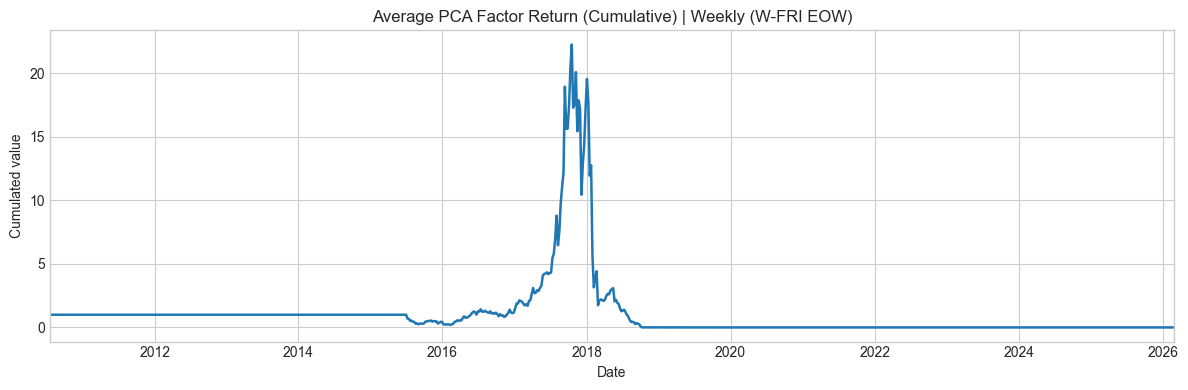

PCA eligibility count tail:


Date
2026-01-30    25
2026-02-06    25
2026-02-13    25
2026-02-20    25
2026-02-27    25
Freq: W-FRI, Name: eligible_count_pca, dtype: int64

In [5]:
## 5) Rolling PCA factor construction

def build_rolling_pca(ret_p, runtime):
    window = runtime['pca_window']
    n_components = CONFIG['n_components']
    standardize = CONFIG.get('standardize', True)
    min_obs = runtime['min_obs']

    factor_cols = [f'F{i+1}' for i in range(n_components)]
    factor_ret = pd.DataFrame(index=ret_p.index, columns=factor_cols, dtype=float)

    loadings_by_t = {}
    elig_count = pd.Series(index=ret_p.index, dtype=float)
    eligibility_mask_by_t = {}

    prev_loadings = None

    for i, t in enumerate(ret_p.index):
        if i < window - 1:
            continue

        win = ret_p.iloc[i - window + 1 : i + 1]
        obs = win.notna().sum()
        elig = obs >= min_obs
        elig = elig.reindex(ret_p.columns).fillna(False)
        # 決定期tで観測不能なETFは投資対象外
        elig = elig & ret_p.loc[t].notna().reindex(ret_p.columns).fillna(False)

        eligibility_mask_by_t[t] = elig
        elig_count.loc[t] = int(elig.sum())

        if int(elig.sum()) < 2:
            continue

        x = win.loc[:, elig.index[elig.values]].copy()

        # 窓内のみで欠損補完（未来情報不使用）
        x = x.apply(lambda col: col.fillna(col.mean()), axis=0)
        x = x.fillna(0.0)

        if standardize:
            mu = x.mean(axis=0)
            sd = x.std(axis=0, ddof=0).replace(0.0, 1.0)
            x_std = (x - mu) / sd
        else:
            x_std = x

        k = min(n_components, x_std.shape[1], x_std.shape[0])
        if k < 1:
            continue

        pca = PCA(n_components=k, random_state=42)
        scores = pca.fit_transform(x_std.values)
        loadings = pd.DataFrame(pca.components_.T, index=x_std.columns, columns=[f'F{i+1}' for i in range(k)])

        # PCA符号の時系列整合
        if prev_loadings is not None:
            common_assets = loadings.index.intersection(prev_loadings.index)
            common_factors = loadings.columns.intersection(prev_loadings.columns)
            for fc in common_factors:
                if len(common_assets) == 0:
                    continue
                sign_anchor = float((loadings.loc[common_assets, fc] * prev_loadings.loc[common_assets, fc]).sum())
                if sign_anchor < 0:
                    loadings[fc] *= -1.0
                    col_idx = list(loadings.columns).index(fc)
                    scores[:, col_idx] *= -1.0

        prev_loadings = loadings.copy()

        f_t = pd.Series(scores[-1, :], index=loadings.columns)
        factor_ret.loc[t, f_t.index] = f_t.values
        loadings_by_t[t] = loadings

    elig_count = elig_count.fillna(0).astype(int).rename('eligible_count_pca')
    elig_count.attrs['eligibility_mask_by_t'] = eligibility_mask_by_t

    return factor_ret, loadings_by_t, elig_count


factor_ret, loadings_by_t, elig_pca_count = build_rolling_pca(ret_p, RUNTIME)

print('PCA factor return sample (tail):')
display(factor_ret.tail())

fig, ax = plt.subplots(figsize=(12, 4))
((1 + factor_ret.fillna(0).mean(axis=1)).cumprod()).plot(ax=ax, linewidth=1.8)
ax.set_title(f"Average PCA Factor Return (Cumulative) | {RUNTIME['frequency_label']}")
ax.set_ylabel('Cumulated value')
plt.tight_layout()
plt.show()

print('PCA eligibility count tail:')
display(elig_pca_count.tail())

Runtime lookbacks(periods): [4, 52]
Runtime skip(periods): 4
Normalized combine_weights(periods): {4: 0.5, 52: 0.5}
Check sum(combine_weights_normalized)= 1.0
exclude_pcs(raw)= [1]
excluded_factor_labels(resolved)= ['F1']


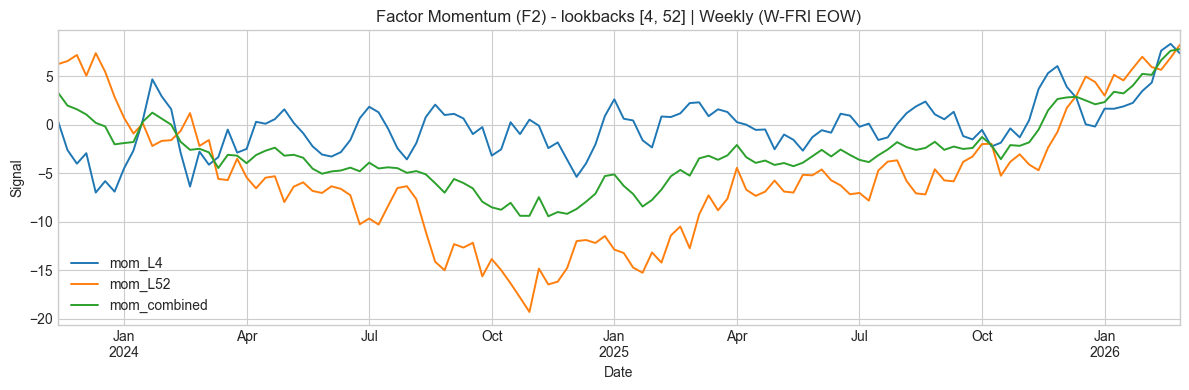

Factor allocation comparison at 2026-02-27


,F1,F2,F3,F4,F5,F6,F7,F8
top_m,0.0000,0.3333,0.3333,0.0000,0.0000,0.3333,0.0000,0.0000
rank,0.0000,0.2381,0.2857,0.0476,0.0952,0.1905,0.1429,0.0000
sign,0.0000,0.2500,0.2500,0.0000,0.0000,0.2500,0.2500,0.0000


In [6]:
## 6) Factor momentum signals (multi-L) + factor allocation

def compute_factor_mom(factor_ret, lookbacks_periods, skip_periods, combine_weights_periods):
    # combine_weights を正規化（未正規化入力でも可）
    lookbacks = sorted(set(int(x) for x in lookbacks_periods))

    raw_w = {int(k): float(v) for k, v in combine_weights_periods.items() if int(k) in lookbacks}
    s = sum(raw_w.values())
    if s == 0:
        norm_w = {int(L): 1.0 / len(lookbacks) for L in lookbacks}
    else:
        norm_w = {int(L): raw_w.get(int(L), 0.0) / s for L in lookbacks}

    mom_parts = {}
    for L in lookbacks:
        L = int(L)
        # 短期lookbackは通常モメンタム、長期lookbackは skip を反映
        start_lag = 1
        if skip_periods > 0 and L > (skip_periods + 1):
            start_lag = skip_periods + 1

        lagged = [factor_ret.shift(j) for j in range(start_lag, L + 1)]
        mom_L = sum(lagged) if lagged else factor_ret * np.nan
        mom_parts[L] = mom_L

    mom_df = sum(norm_w[L] * mom_parts[L] for L in lookbacks)
    return mom_df, mom_parts, norm_w


def allocate_factor_weights(mom_t, method='top_m', top_m=3, long_only=True):
    x = mom_t.dropna().copy()
    if len(x) == 0:
        return pd.Series(index=mom_t.index, data=0.0)

    if method == 'top_m':
        winners = x.nlargest(min(top_m, len(x)))
        w = pd.Series(0.0, index=x.index)
        if long_only:
            winners = winners[winners > 0]
            if len(winners) > 0:
                w.loc[winners.index] = 1.0 / len(winners)
        else:
            w.loc[winners.index] = 1.0 / len(winners)

    elif method == 'rank':
        r = x.rank(method='average', ascending=True)
        w = r - r.min()
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w - w.mean())

    elif method == 'sign':
        w = np.sign(x)
        if long_only:
            w = normalize_long_only(w)
        else:
            w = normalize_ls(w)

    else:
        raise ValueError(f'Unknown factor_weighting method: {method}')

    # full factor indexへ戻す
    out = pd.Series(0.0, index=mom_t.index)
    out.loc[w.index] = w.values

    if long_only:
        out = normalize_long_only(out)
    else:
        out = normalize_ls(out)

    return out


factor_mom_raw, mom_parts, norm_cw = compute_factor_mom(
    factor_ret=factor_ret,
    lookbacks_periods=RUNTIME['lookbacks_periods'],
    skip_periods=RUNTIME['skip_periods'],
    combine_weights_periods=RUNTIME['combine_weights_periods'],
)

excluded_factor_labels = resolve_excluded_factor_labels(CONFIG.get('exclude_pcs', []), factor_mom_raw.columns)
factor_mom = apply_factor_exclusion(factor_mom_raw, excluded_factor_labels)

print('Runtime lookbacks(periods):', RUNTIME['lookbacks_periods'])
print('Runtime skip(periods):', RUNTIME['skip_periods'])
print('Normalized combine_weights(periods):', norm_cw)
print('Check sum(combine_weights_normalized)=', sum(norm_cw.values()))
print('exclude_pcs(raw)=', CONFIG.get('exclude_pcs', []))
print('excluded_factor_labels(resolved)=', sorted(excluded_factor_labels))

if len(excluded_factor_labels) == len(factor_mom.columns):
    print('[INFO] All factor sleeves are excluded: allocation will be cash (zero weights).')

lookbacks_sorted = sorted(mom_parts.keys())
available_plot_factors = [c for c in factor_mom.columns if c not in excluded_factor_labels]
if len(available_plot_factors) == 0:
    print('[INFO] Factor momentum plot skipped because all factors are excluded.')
else:
    sample_factor = available_plot_factors[0]
    plot_dict = {f"mom_L{lb}": mom_parts[lb][sample_factor] for lb in lookbacks_sorted}
    plot_dict['mom_combined'] = factor_mom[sample_factor]
    plot_df = pd.DataFrame(plot_dict).dropna()

    if len(plot_df) == 0:
        print(f"[INFO] No plottable momentum sample for {sample_factor}.")
    else:
        fig, ax = plt.subplots(figsize=(12, 4))
        plot_df.tail(120).plot(ax=ax, linewidth=1.4)
        ax.set_title(f"Factor Momentum ({sample_factor}) - lookbacks {lookbacks_sorted} | {RUNTIME['frequency_label']}")
        ax.set_ylabel('Signal')
        plt.tight_layout()
        plt.show()

# factor_weighting 3方式の比較（同一期）
valid_idx = factor_mom.dropna(how='all').index
if len(valid_idx) == 0:
    print('[INFO] Allocation snapshot: all factors are excluded or unavailable. Returning zero weights.')
    zero_alloc = pd.Series(0.0, index=factor_mom.columns)
    display(pd.DataFrame({'top_m': zero_alloc, 'rank': zero_alloc, 'sign': zero_alloc}).T)
else:
    latest_t = valid_idx[-1]
    w_top = allocate_factor_weights(factor_mom.loc[latest_t], method='top_m', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])
    w_rank = allocate_factor_weights(factor_mom.loc[latest_t], method='rank', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])
    w_sign = allocate_factor_weights(factor_mom.loc[latest_t], method='sign', top_m=CONFIG['top_m_factors'], long_only=CONFIG['long_only'])

    print(f'Factor allocation comparison at {latest_t.date()}')
    display(pd.DataFrame({'top_m': w_top, 'rank': w_rank, 'sign': w_sign}).T)


Gate quick summary (tail):


,breadth,dispersion,disp_threshold,gate_on,gate_reason
Date,,,,,
2026-01-09,0.4286,0.0249,0.0287,False,
2026-01-16,0.4286,0.0362,0.0287,False,
2026-01-23,0.5714,0.0267,0.0291,False,
2026-01-30,0.5714,0.0276,0.0291,False,
2026-02-06,0.5714,0.0497,0.0291,False,
2026-02-13,0.4286,0.0316,0.0293,False,
2026-02-20,0.4286,0.0296,0.0294,False,
2026-02-27,0.5714,0.0144,0.0295,False,


PC exclusion used in S2-L: ['F1']
S2-L decision periods: 474 (skipped=341)
S2-L gate_on count: 0 (0.00%)
S2-L cash decisions due to PC exclusion: 0
S2-L net return periods: 473


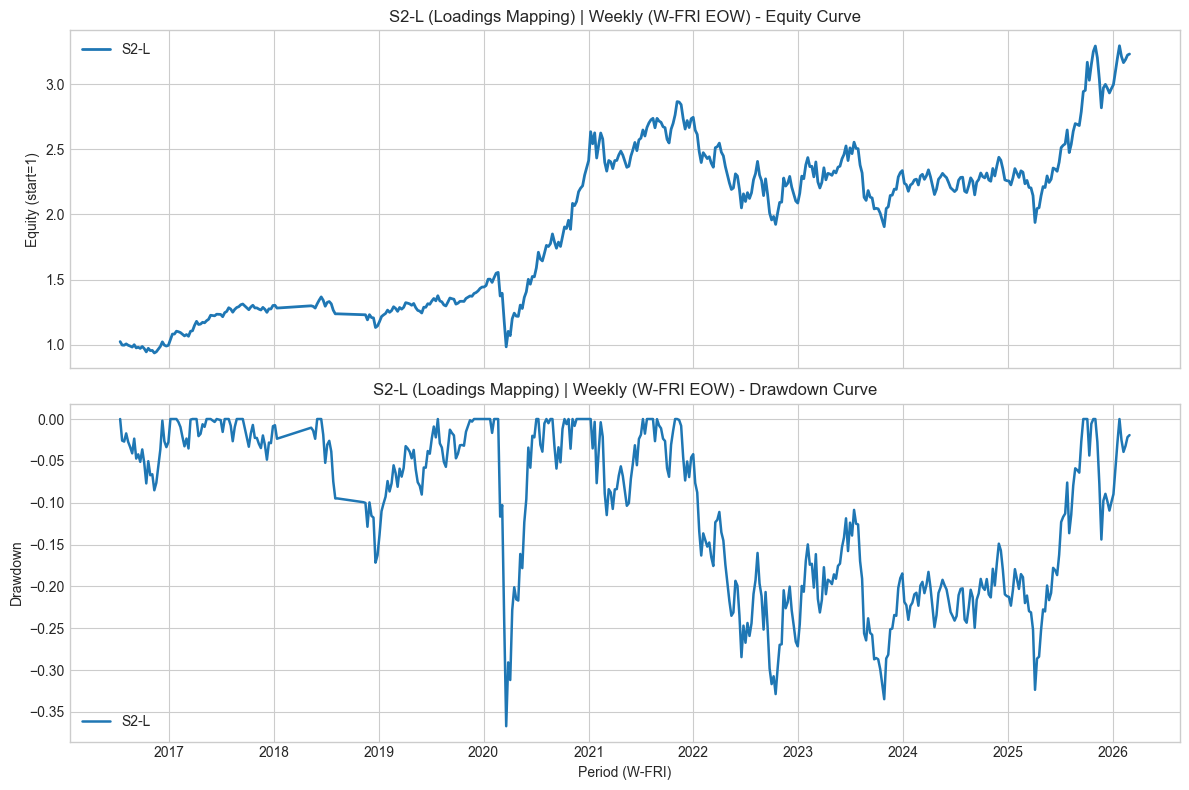

,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
2026-01-30,0.0000,0.0000,0.0000,0.0259,0.0320,0.0000,0.0000,0.0000,0.0000,0.1732,...,0.0000,0.0211,0.1710,0.0000,0.0000,0.0989,0.1268,0.0000,0.0261,0.0000
2026-02-06,0.0000,0.0000,0.0020,0.0125,0.0300,0.0000,0.0000,0.0000,0.0000,0.1778,...,0.0000,0.0792,0.1887,0.0000,0.0743,0.0828,0.0000,0.0240,0.0000,0.0000
2026-02-13,0.0000,0.0000,0.0101,0.0196,0.0365,0.0000,0.0000,0.0000,0.0000,0.1681,...,0.0000,0.0804,0.1789,0.0000,0.0828,0.0775,0.0000,0.0281,0.0000,0.0000
2026-02-20,0.0000,0.0000,0.0046,0.0375,0.0522,0.0000,0.0000,0.0000,0.0000,0.1681,...,0.0000,0.0677,0.1765,0.0000,0.0782,0.0795,0.0000,0.0275,0.0000,0.0000
2026-02-27,0.0000,0.0000,0.0061,0.0488,0.0628,0.0000,0.0000,0.0000,0.0000,0.1681,...,0.0000,0.0576,0.1657,0.0000,0.0818,0.0777,0.0000,0.0321,0.0000,0.0000


In [7]:
## 7) S2-L: mapping(loadings) + backtest + plots

def map_loadings_to_etf(loadings_t, w_factor, elig_mask_t, cap=None):
    all_assets = elig_mask_t.index

    fac = loadings_t.columns.intersection(w_factor.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    raw = loadings_t[fac].dot(w_factor[fac])

    w = pd.Series(0.0, index=all_assets)
    w.loc[raw.index] = raw.values
    w.loc[~elig_mask_t] = 0.0

    if CONFIG['long_only']:
        w = normalize_long_only(w)
    else:
        w = normalize_ls(w)

    w = apply_weight_cap(w, cap=cap)
    return w


all_tickers = ret_p.columns.tolist()
eligibility_mask_by_t = elig_pca_count.attrs['eligibility_mask_by_t']

# Build common risk gates (applied to S2-L / S2-R only, EQW remains ungated)
gate_df = build_risk_gates(
    factor_mom=factor_mom,
    ret_p=ret_p,
    eligibility_mask_by_t=eligibility_mask_by_t,
    runtime=RUNTIME,
    config=CONFIG,
)

print('Gate quick summary (tail):')
display(gate_df[['breadth', 'dispersion', 'disp_threshold', 'gate_on', 'gate_reason']].tail(8))
print('PC exclusion used in S2-L:', sorted(excluded_factor_labels))

weights_s2l_dict = {}
skipped_s2l = 0
gate_on_count_s2l = 0
excluded_cash_count_s2l = 0
zero_w = pd.Series(0.0, index=all_tickers)

for t in sorted(factor_mom.index.intersection(ret_p.index)):
    mom_t_raw = factor_mom_raw.loc[t]
    mom_t = factor_mom.loc[t]

    # no signal due to warm-up / unavailable factors
    if mom_t_raw.isna().all():
        skipped_s2l += 1
        continue

    gate_on = bool(gate_df.loc[t, 'gate_on']) if t in gate_df.index else False

    # all factors excluded at this period -> explicit cash decision
    if mom_t.isna().all():
        weights_s2l_dict[t] = zero_w.copy()
        excluded_cash_count_s2l += 1
        if gate_on:
            gate_on_count_s2l += 1
        continue

    # If loadings are unavailable but gate is ON, keep explicit cash decision for turnover continuity
    if t not in loadings_by_t:
        if gate_on:
            weights_s2l_dict[t] = zero_w.copy()
            gate_on_count_s2l += 1
        else:
            skipped_s2l += 1
        continue

    w_factor_t = allocate_factor_weights(
        mom_t,
        method=CONFIG['factor_weighting'],
        top_m=CONFIG['top_m_factors'],
        long_only=CONFIG['long_only'],
    )

    elig_t = eligibility_mask_by_t.get(t, pd.Series(False, index=all_tickers)).reindex(all_tickers).fillna(False)
    w_etf_t = map_loadings_to_etf(loadings_by_t[t], w_factor_t, elig_t, cap=CONFIG['weight_cap'])
    w_etf_t = apply_gate_to_weight(w_etf_t, gate_on=gate_on, action='cash')

    if gate_on:
        gate_on_count_s2l += 1

    if np.isclose(w_etf_t.sum(), 0.0) and (not gate_on):
        skipped_s2l += 1
        continue

    weights_s2l_dict[t] = w_etf_t

weights_s2l = pd.DataFrame.from_dict(weights_s2l_dict, orient='index').reindex(columns=all_tickers).fillna(0.0).sort_index()

gross_s2l, net_s2l, turnover_s2l, equity_s2l, dd_s2l = run_backtest(weights_s2l, ret_p, CONFIG['cost_bps'])

gate_on_ratio_s2l = (gate_on_count_s2l / len(weights_s2l)) if len(weights_s2l) > 0 else 0.0

print(f'S2-L decision periods: {len(weights_s2l)} (skipped={skipped_s2l})')
print(f'S2-L gate_on count: {gate_on_count_s2l} ({gate_on_ratio_s2l:.2%})')
print(f'S2-L cash decisions due to PC exclusion: {excluded_cash_count_s2l}')
print(f'S2-L net return periods: {len(net_s2l)}')

plot_equity_dd(
    equity_map={'S2-L': equity_s2l},
    dd_map={'S2-L': dd_s2l},
    title_prefix=f"S2-L (Loadings Mapping) | {RUNTIME['frequency_label']}"
)

weights_s2l.tail()

S2-R decision periods: 287 (skipped=528)
S2-R gate_on count: 0 (0.00%)
S2-R cash decisions due to PC exclusion: 0
S2-R net return periods: 286


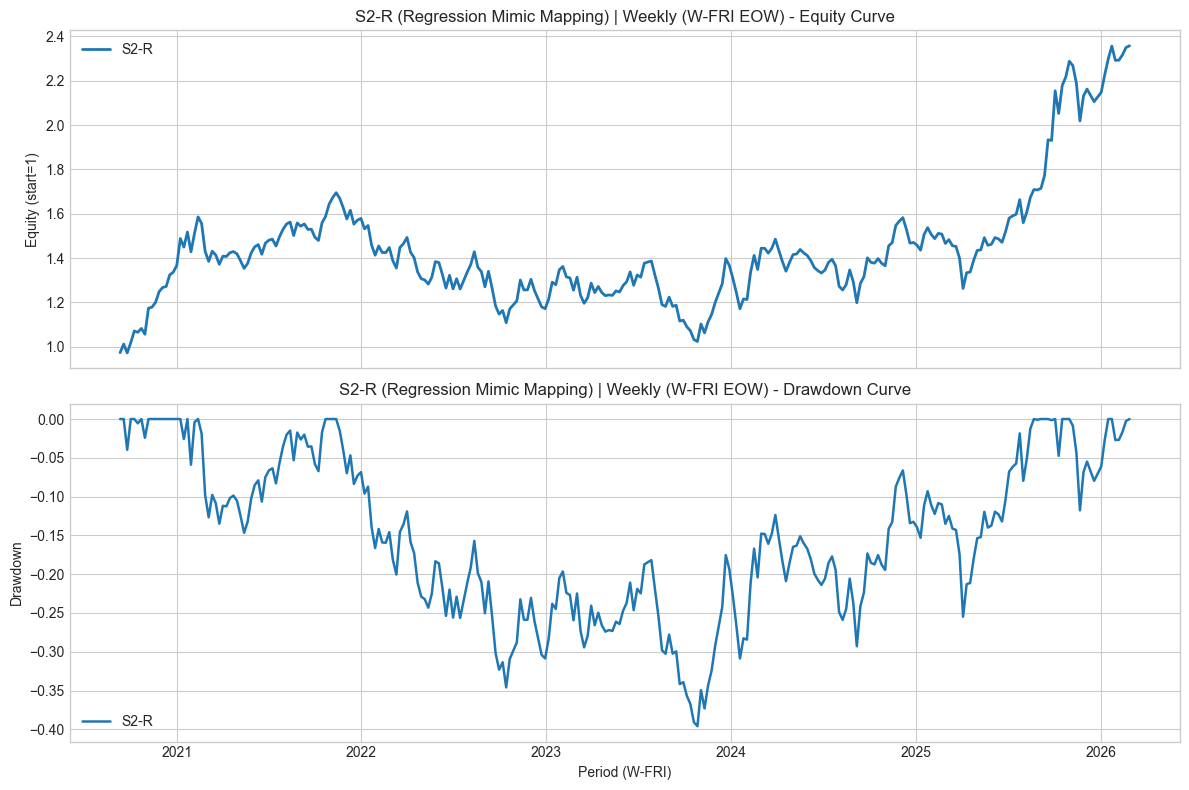

,AGNG,AIQ,AQWA,BITS,BKCH,BOTZ,BUG,CHPX,CLOU,CTEC,...,IPAV,KROP,LIT,MILN,PAVE,RNRG,SHLD,SNSR,SOCL,ZAP
2026-01-30,0.0398,0.0000,0.0000,0.0000,0.0000,0.0157,0.0000,0.0000,0.0000,0.1952,...,0.0000,0.0069,0.2104,0.0000,0.0019,0.0980,0.0239,0.0265,0.0000,0.0000
2026-02-06,0.0000,0.0065,0.0288,0.0000,0.0000,0.0440,0.0000,0.0000,0.0000,0.1334,...,0.0000,0.1148,0.1347,0.0000,0.1049,0.0444,0.0000,0.0762,0.0000,0.0000
2026-02-13,0.0000,0.0061,0.0292,0.0000,0.0000,0.0444,0.0000,0.0000,0.0000,0.1290,...,0.0000,0.1175,0.1350,0.0000,0.1050,0.0427,0.0000,0.0782,0.0000,0.0000
2026-02-20,0.0000,0.0057,0.0290,0.0000,0.0000,0.0447,0.0000,0.0000,0.0000,0.1291,...,0.0000,0.1177,0.1331,0.0000,0.1065,0.0419,0.0000,0.0783,0.0000,0.0000
2026-02-27,0.0000,0.0057,0.0290,0.0000,0.0000,0.0447,0.0000,0.0000,0.0000,0.1290,...,0.0000,0.1177,0.1331,0.0000,0.1065,0.0418,0.0000,0.0783,0.0000,0.0000


In [8]:
## 8) S2-R: mapping(regression mimic) + backtest + plots

def estimate_regression_betas(ret_p, factor_ret, t, window_periods=60, min_obs=24):
    if t not in ret_p.index:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    pos = ret_p.index.get_loc(t)
    if pos < window_periods - 1:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    win_idx = ret_p.index[pos - window_periods + 1 : pos + 1]
    X_all = factor_ret.reindex(win_idx)

    valid_factor_cols = [c for c in factor_ret.columns if pd.notna(factor_ret.loc[t, c])]
    if len(valid_factor_cols) == 0:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    X_all = X_all[valid_factor_cols]

    beta_rows = {}
    for tk in ret_p.columns:
        if pd.isna(ret_p.loc[t, tk]):
            continue
        y = ret_p.loc[win_idx, tk]
        reg_df = pd.concat([y.rename('y'), X_all], axis=1).dropna()

        need_obs = max(min_obs, len(valid_factor_cols) + 1)
        if len(reg_df) < need_obs:
            continue

        yv = reg_df['y'].values
        xv = reg_df[valid_factor_cols].values
        xv = np.column_stack([np.ones(len(xv)), xv])

        coef = np.linalg.lstsq(xv, yv, rcond=None)[0]
        beta_rows[tk] = coef[1:]

    if not beta_rows:
        return pd.DataFrame(), pd.Series(False, index=ret_p.columns)

    beta_mat = pd.DataFrame.from_dict(beta_rows, orient='index', columns=valid_factor_cols)
    elig = pd.Series(False, index=ret_p.columns)
    elig.loc[beta_mat.index] = True

    return beta_mat, elig


def map_regression_to_etf(beta_t, w_factor, elig_mask_t, cap=None):
    all_assets = elig_mask_t.index
    if beta_t.empty:
        return pd.Series(0.0, index=all_assets)

    fac = beta_t.columns.intersection(w_factor.index)
    if len(fac) == 0:
        return pd.Series(0.0, index=all_assets)

    raw = beta_t[fac].dot(w_factor[fac])

    w = pd.Series(0.0, index=all_assets)
    w.loc[raw.index] = raw.values
    w.loc[~elig_mask_t] = 0.0

    if CONFIG['long_only']:
        w = normalize_long_only(w)
    else:
        w = normalize_ls(w)

    w = apply_weight_cap(w, cap=cap)
    return w


weights_s2r_dict = {}
elig_reg_count = pd.Series(index=ret_p.index, dtype=float)
skipped_s2r = 0
gate_on_count_s2r = 0
excluded_cash_count_s2r = 0
zero_w = pd.Series(0.0, index=all_tickers)

for t in sorted(factor_mom.index.intersection(ret_p.index)):
    mom_t_raw = factor_mom_raw.loc[t]
    mom_t = factor_mom.loc[t]

    # no signal due to warm-up / unavailable factors
    if mom_t_raw.isna().all():
        skipped_s2r += 1
        continue

    gate_on = bool(gate_df.loc[t, 'gate_on']) if t in gate_df.index else False

    beta_t, elig_t = estimate_regression_betas(
        ret_p=ret_p,
        factor_ret=factor_ret,
        t=t,
        window_periods=RUNTIME['reg_window'],
        min_obs=RUNTIME['min_obs'],
    )

    elig_reg_count.loc[t] = int(elig_t.sum())

    # all factors excluded at this period -> explicit cash decision
    if mom_t.isna().all():
        weights_s2r_dict[t] = zero_w.copy()
        excluded_cash_count_s2r += 1
        if gate_on:
            gate_on_count_s2r += 1
        continue

    if beta_t.empty:
        if gate_on:
            weights_s2r_dict[t] = zero_w.copy()
            gate_on_count_s2r += 1
        else:
            skipped_s2r += 1
        continue

    w_factor_t = allocate_factor_weights(
        mom_t,
        method=CONFIG['factor_weighting'],
        top_m=CONFIG['top_m_factors'],
        long_only=CONFIG['long_only'],
    )

    w_etf_t = map_regression_to_etf(beta_t, w_factor_t, elig_t, cap=CONFIG['weight_cap'])
    w_etf_t = apply_gate_to_weight(w_etf_t, gate_on=gate_on, action='cash')

    if gate_on:
        gate_on_count_s2r += 1

    if np.isclose(w_etf_t.sum(), 0.0) and (not gate_on):
        skipped_s2r += 1
        continue

    weights_s2r_dict[t] = w_etf_t

weights_s2r = pd.DataFrame.from_dict(weights_s2r_dict, orient='index').reindex(columns=all_tickers).fillna(0.0).sort_index()
elig_reg_count = elig_reg_count.fillna(0).astype(int).rename('eligible_count_reg')

gross_s2r, net_s2r, turnover_s2r, equity_s2r, dd_s2r = run_backtest(weights_s2r, ret_p, CONFIG['cost_bps'])

gate_on_ratio_s2r = (gate_on_count_s2r / len(weights_s2r)) if len(weights_s2r) > 0 else 0.0

print(f'S2-R decision periods: {len(weights_s2r)} (skipped={skipped_s2r})')
print(f'S2-R gate_on count: {gate_on_count_s2r} ({gate_on_ratio_s2r:.2%})')
print(f'S2-R cash decisions due to PC exclusion: {excluded_cash_count_s2r}')
print(f'S2-R net return periods: {len(net_s2r)}')

plot_equity_dd(
    equity_map={'S2-R': equity_s2r},
    dd_map={'S2-R': dd_s2r},
    title_prefix=f"S2-R (Regression Mimic Mapping) | {RUNTIME['frequency_label']}"
)

weights_s2r.tail()

Common comparison window: 2020-09-11 -> 2026-02-27 (286 periods)


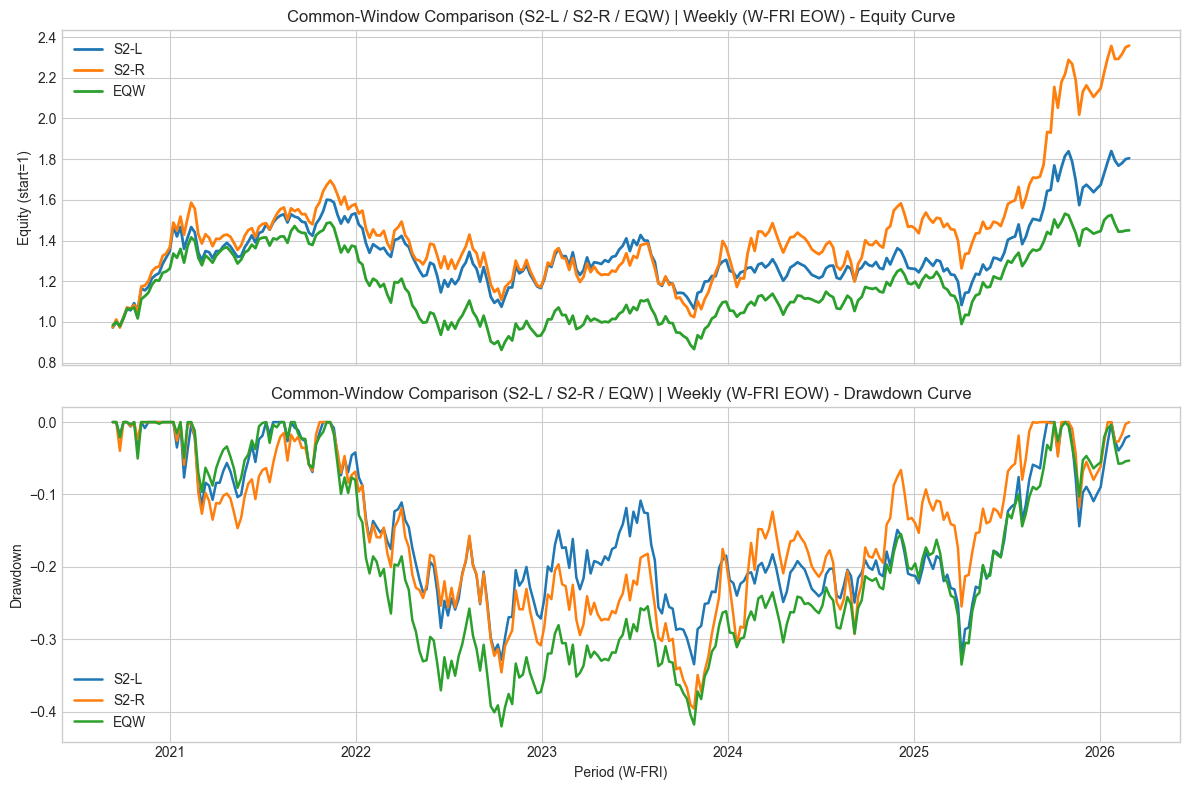

In [9]:
## 9) Compare (S2-L vs S2-R vs EQW) equity & drawdown

# EQW eligibility: PCAの時点tで投資候補になったETFを採用
eligibility_eqw = pd.DataFrame(
    {t: m.reindex(all_tickers).fillna(False) for t, m in eligibility_mask_by_t.items()}
).T.sort_index().astype(bool)
elig_eqw_count = eligibility_eqw.sum(axis=1).rename('eligible_count_eqw')

eqw_net, eqw_turnover, eqw_equity, eqw_dd = build_eqw(eligibility_eqw, ret_p, CONFIG['cost_bps'])

common_idx = net_s2l.index.intersection(net_s2r.index).intersection(eqw_net.index)
if len(common_idx) == 0:
    raise ValueError('No common comparison period among S2-L, S2-R, EQW.')

common_start = common_idx.min()
common_end = common_idx.max()
print(f'Common comparison window: {common_start.date()} -> {common_end.date()} ({len(common_idx)} periods)')

net_s2l_c = net_s2l.reindex(common_idx)
net_s2r_c = net_s2r.reindex(common_idx)
eqw_net_c = eqw_net.reindex(common_idx)

turn_s2l_c = turnover_s2l.reindex(common_idx)
turn_s2r_c = turnover_s2r.reindex(common_idx)
eqw_turn_c = eqw_turnover.reindex(common_idx)

equity_s2l_c = (1 + net_s2l_c).cumprod()
equity_s2r_c = (1 + net_s2r_c).cumprod()
eqw_equity_c = (1 + eqw_net_c).cumprod()

dd_s2l_c = calc_drawdown(equity_s2l_c)
dd_s2r_c = calc_drawdown(equity_s2r_c)
eqw_dd_c = calc_drawdown(eqw_equity_c)

plot_equity_dd(
    equity_map={'S2-L': equity_s2l_c, 'S2-R': equity_s2r_c, 'EQW': eqw_equity_c},
    dd_map={'S2-L': dd_s2l_c, 'S2-R': dd_s2r_c, 'EQW': eqw_dd_c},
    title_prefix=f"Common-Window Comparison (S2-L / S2-R / EQW) | {RUNTIME['frequency_label']}"
)

In [10]:
## 10) Metrics table (CAGR/Vol/Sharpe/MDD/Turnover/Hit)

metrics = pd.DataFrame({
    'S2-L': calc_metrics(net_s2l_c, turn_s2l_c, RUNTIME['periods_per_year']),
    'S2-R': calc_metrics(net_s2r_c, turn_s2r_c, RUNTIME['periods_per_year']),
    'EQW': calc_metrics(eqw_net_c, eqw_turn_c, RUNTIME['periods_per_year']),
}).T

print('Performance metrics on common window:')
display(metrics)

# basic sanity checks
assert np.isfinite(metrics[['CAGR','Vol','Sharpe','MDD','Turnover','Hit']].values).all(), 'Metrics contain NaN/inf.'
print('Metrics sanity check passed.')

Performance metrics on common window:


,CAGR,Vol,Sharpe,MDD,Turnover,Hit
S2-L,0.1133,0.2259,0.5886,-0.3347,0.1221,0.5210
S2-R,0.1688,0.2601,0.7297,-0.3960,0.1039,0.5385
EQW,0.0699,0.2220,0.4154,-0.4205,0.0027,0.5175


Metrics sanity check passed.


Leak check sample (shift consistency):


,strategy,decision_period,max_signal_data_period,applied_return_period
0,S2-L,2016-07-08,2016-07-01,2016-07-15
1,S2-L,2016-07-15,2016-07-08,2016-07-22
2,S2-L,2016-07-22,2016-07-15,2016-07-29
3,S2-L,2016-07-29,2016-07-22,2016-08-05
4,S2-L,2016-08-05,2016-07-29,2016-08-12
5,S2-R,2020-09-04,2020-08-28,2020-09-11
6,S2-R,2020-09-11,2020-09-04,2020-09-18
7,S2-R,2020-09-18,2020-09-11,2020-09-25
8,S2-R,2020-09-25,2020-09-18,2020-10-02
9,S2-R,2020-10-02,2020-09-25,2020-10-09


Leak check passed.


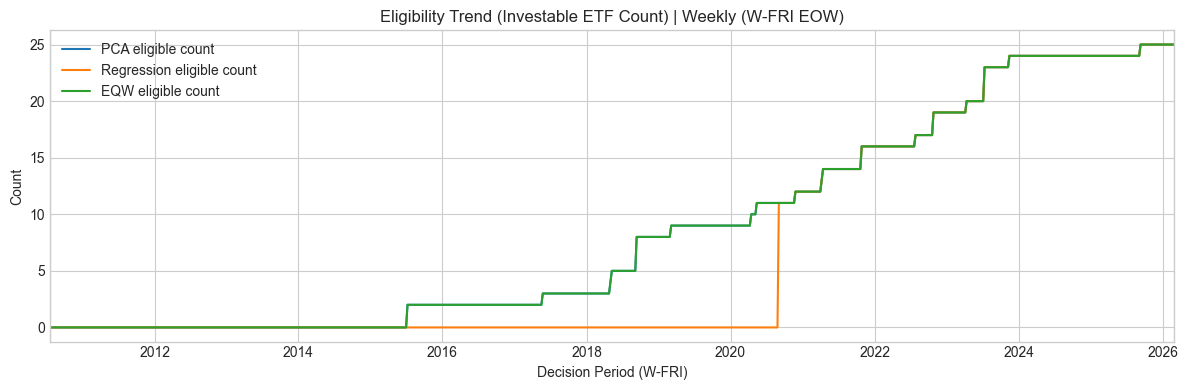

Eligibility (tail):


,PCA eligible count,Regression eligible count,EQW eligible count
2025-12-12,25,25,25.0000
2025-12-19,25,25,25.0000
2025-12-26,25,25,25.0000
2026-01-02,25,25,25.0000
2026-01-09,25,25,25.0000
2026-01-16,25,25,25.0000
2026-01-23,25,25,25.0000
2026-01-30,25,25,25.0000
2026-02-06,25,25,25.0000
2026-02-13,25,25,25.0000


PC exclusion diagnostics:
exclude_pcs(raw)=[1]
excluded_factor_labels(resolved)=['F1']
effective_factor_count_by_period (tail):


Date
2025-12-12    7
2025-12-19    7
2025-12-26    7
2026-01-02    7
2026-01-09    7
2026-01-16    7
2026-01-23    7
2026-01-30    7
2026-02-06    7
2026-02-13    7
2026-02-20    7
2026-02-27    7
Freq: W-FRI, Name: effective_factor_count, dtype: int64

Gate configuration:
use_breadth_gate=False (threshold=0.6), use_dispersion_gate=False (q_high=0.8, window=260 periods)
gate_on rate (all periods): 0.00%
Gate tail (breadth/dispersion):


,breadth,breadth_pass,dispersion,disp_threshold,dispersion_pass,gate_on,gate_reason
Date,,,,,,,
2025-12-12,0.4286,True,0.0181,0.0291,True,False,
2025-12-19,0.5714,True,0.0155,0.0291,True,False,
2025-12-26,0.5714,True,0.0171,0.0291,True,False,
2026-01-02,0.5714,True,0.0250,0.0291,True,False,
2026-01-09,0.4286,True,0.0249,0.0287,True,False,
2026-01-16,0.4286,True,0.0362,0.0287,True,False,
2026-01-23,0.5714,True,0.0267,0.0291,True,False,
2026-01-30,0.5714,True,0.0276,0.0291,True,False,
2026-02-06,0.5714,True,0.0497,0.0291,True,False,


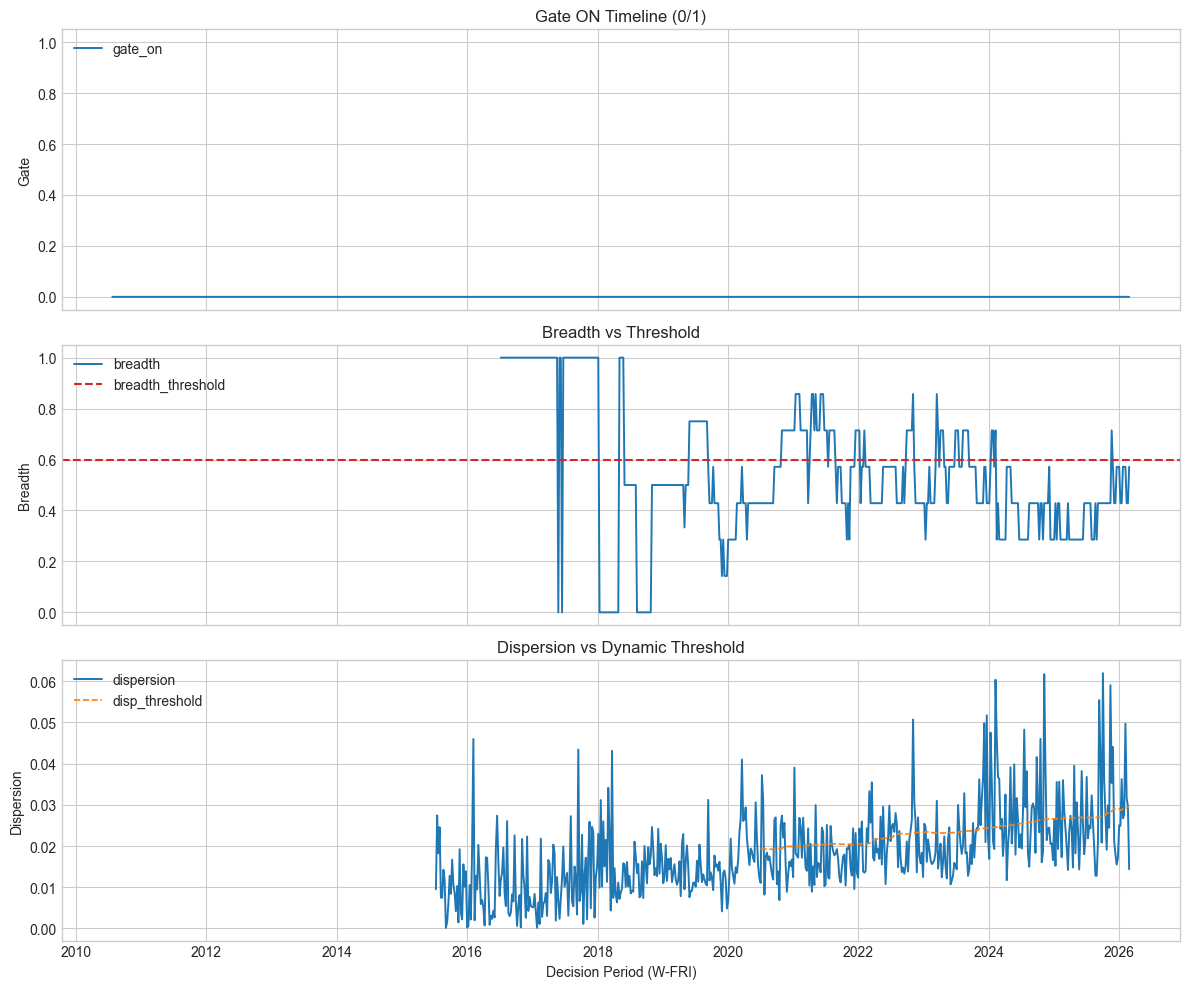

In [11]:
## 11) Diagnostics (leak check / eligibility counts + risk gates)

# leak check: factor signal uses <= decision period data, and return application is t+1 period

def make_leak_check_table(net_series, ret_index, name='strategy'):
    decision_periods = net_series.attrs.get('decision_periods', pd.DatetimeIndex([], name='decision_period'))
    applied_periods = net_series.index

    n = min(len(decision_periods), len(applied_periods))
    decision_periods = decision_periods[:n]
    applied_periods = applied_periods[:n]

    prev_periods = [prev_period_index(ret_index, t) for t in decision_periods]

    leak_tbl = pd.DataFrame({
        'strategy': name,
        'decision_period': decision_periods,
        'max_signal_data_period': prev_periods,
        'applied_return_period': applied_periods,
    })

    return leak_tbl


leak_l = make_leak_check_table(net_s2l, ret_p.index, name='S2-L')
leak_r = make_leak_check_table(net_s2r, ret_p.index, name='S2-R')
leak_tbl = pd.concat([leak_l.head(5), leak_r.head(5)], axis=0).reset_index(drop=True)

print('Leak check sample (shift consistency):')
display(leak_tbl)

valid_leak = leak_tbl.dropna(subset=['max_signal_data_period', 'decision_period', 'applied_return_period'])
assert (valid_leak['max_signal_data_period'] <= valid_leak['decision_period']).all(), 'Leak check failed: signal uses future info.'
assert (valid_leak['decision_period'] < valid_leak['applied_return_period']).all(), 'Leak check failed: weights not applied to next period.'
print('Leak check passed.')

# eligibility trend
elig_plot = pd.concat([
    elig_pca_count.rename('PCA eligible count'),
    elig_reg_count.rename('Regression eligible count'),
    elig_eqw_count.rename('EQW eligible count')
], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 4))
elig_plot.plot(ax=ax, linewidth=1.5)
ax.set_title(f"Eligibility Trend (Investable ETF Count) | {RUNTIME['frequency_label']}")
ax.set_ylabel('Count')
ax.set_xlabel(f"Decision Period ({RUNTIME['rule']})")
plt.tight_layout()
plt.show()

print('Eligibility (tail):')
display(elig_plot.tail(12))



# PC exclusion diagnostics
print('PC exclusion diagnostics:')
print(f"exclude_pcs(raw)={CONFIG.get('exclude_pcs', [])}")
print(f"excluded_factor_labels(resolved)={sorted(excluded_factor_labels)}")

effective_factor_count_by_period = factor_mom.notna().sum(axis=1).rename('effective_factor_count')
print('effective_factor_count_by_period (tail):')
display(effective_factor_count_by_period.tail(12))

# Gate diagnostics (S2-only)
print('Gate configuration:')
print(
    f"use_breadth_gate={CONFIG['use_breadth_gate']} (threshold={CONFIG['breadth_threshold']}), "
    f"use_dispersion_gate={CONFIG['use_dispersion_gate']} (q_high={CONFIG['dispersion_q_high']}, "
    f"window={RUNTIME['dispersion_window']} periods)"
)

gate_on_rate = float(gate_df['gate_on'].mean()) if len(gate_df) > 0 else np.nan
print(f"gate_on rate (all periods): {gate_on_rate:.2%}")

print('Gate tail (breadth/dispersion):')
display(gate_df[['breadth', 'breadth_pass', 'dispersion', 'disp_threshold', 'dispersion_pass', 'gate_on', 'gate_reason']].tail(12))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].step(gate_df.index, gate_df['gate_on'].astype(int), where='post', linewidth=1.4, label='gate_on')
axes[0].set_title('Gate ON Timeline (0/1)')
axes[0].set_ylabel('Gate')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(loc='upper left')

axes[1].plot(gate_df.index, gate_df['breadth'], linewidth=1.4, label='breadth')
axes[1].axhline(CONFIG['breadth_threshold'], color='tab:red', linestyle='--', label='breadth_threshold')
axes[1].set_title('Breadth vs Threshold')
axes[1].set_ylabel('Breadth')
axes[1].legend(loc='upper left')

axes[2].plot(gate_df.index, gate_df['dispersion'], linewidth=1.4, label='dispersion')
axes[2].plot(gate_df.index, gate_df['disp_threshold'], linewidth=1.2, linestyle='--', label='disp_threshold')
axes[2].set_title('Dispersion vs Dynamic Threshold')
axes[2].set_ylabel('Dispersion')
axes[2].set_xlabel(f"Decision Period ({RUNTIME['rule']})")
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 12) PPO特徴量（tまでの情報のみ）

In [12]:
all_tickers = ret_p.columns.tolist()
factor_cols = factor_mom.columns.tolist()

eligibility_df = pd.DataFrame(
    {t: m.reindex(all_tickers).fillna(False) for t, m in eligibility_mask_by_t.items()}
).T.sort_index().astype(bool)


def load_vix_local_csv(path, date_col='Date', close_col='Close'):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'VIX local CSV not found: {path}')

    df = pd.read_csv(path)
    required = {date_col, close_col}
    if not required.issubset(set(df.columns)):
        raise ValueError(f'VIX CSV must contain columns {sorted(required)}. got={df.columns.tolist()}')

    out = df[[date_col, close_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out[close_col] = pd.to_numeric(out[close_col], errors='coerce')
    out = out.dropna(subset=[date_col, close_col])
    out = out.sort_values(date_col).drop_duplicates(subset=[date_col], keep='last')
    out = out.set_index(date_col)

    s = out[close_col].rename('vix_close')
    if not s.index.is_monotonic_increasing:
        s = s.sort_index()
    return s


def build_vix_features(vix_daily, rule, runtime, zscore_window_periods):
    vix_level = vix_daily.resample(rule).last().rename('vix_level')
    vix_ret_1 = vix_level.pct_change().rename('vix_ret_1')

    w = max(2, int(zscore_window_periods))
    mu = vix_level.shift(1).rolling(window=w, min_periods=w).mean()
    sd = vix_level.shift(1).rolling(window=w, min_periods=w).std(ddof=0).replace(0.0, np.nan)
    vix_z = ((vix_level - mu) / sd).rename('vix_zscore')

    out = pd.concat([vix_level, vix_ret_1, vix_z], axis=1)
    out = out.ffill().fillna(0.0)
    return out


def build_rl_features(ret_p, factor_mom, eligibility_by_t, macro_features=None, lags=(0, 1, 4, 12), cs_mom_lookback=12):
    blocks = []

    # 価格リターンのラグ特徴（t, t-1, t-4, t-12 など）
    for lag in lags:
        lag_df = ret_p.shift(int(lag)).copy()
        lag_df.columns = [f'ret_lag{int(lag)}__{c}' for c in lag_df.columns]
        blocks.append(lag_df)

    # 横断面モメンタム順位（時点tで利用可能な銘柄内）
    cs_mom = ret_p.fillna(0.0).rolling(int(cs_mom_lookback), min_periods=2).sum()
    cs_rank = pd.DataFrame(index=ret_p.index, columns=ret_p.columns, dtype=float)

    for t in ret_p.index:
        if t in eligibility_by_t.index:
            elig_t = eligibility_by_t.loc[t].reindex(ret_p.columns).fillna(False)
        else:
            elig_t = pd.Series(False, index=ret_p.columns)

        vals = cs_mom.loc[t].where(elig_t).dropna()
        if len(vals) > 0:
            cs_rank.loc[t, vals.index] = vals.rank(method='average', pct=True)

    cs_rank = cs_rank.fillna(0.0)
    cs_rank.columns = [f'cs_rank__{c}' for c in cs_rank.columns]
    blocks.append(cs_rank)

    fac = factor_mom.reindex(ret_p.index).fillna(0.0).copy()
    fac.columns = [f'factor_mom__{c}' for c in fac.columns]
    blocks.append(fac)

    elig_feat = eligibility_by_t.reindex(ret_p.index).reindex(columns=ret_p.columns).fillna(False).astype(float)
    elig_feat.columns = [f'elig__{c}' for c in elig_feat.columns]
    blocks.append(elig_feat)

    if macro_features is not None and len(macro_features.columns) > 0:
        macro_aligned = macro_features.reindex(ret_p.index).ffill().fillna(0.0)
        blocks.append(macro_aligned)

    feat = pd.concat(blocks, axis=1).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    valid_idx = [t for t in feat.index if next_period_index(ret_p.index, t) is not None]
    feat = feat.loc[valid_idx].sort_index()

    return feat


vix_cfg = CONFIG['rl']['macro']
vix_features = pd.DataFrame(index=ret_p.index)

if bool(vix_cfg.get('enable_vix', False)):
    if str(vix_cfg.get('source', '')).lower() != 'local_csv':
        raise ValueError("Only local_csv source is supported for VIX in this notebook.")

    vix_daily = load_vix_local_csv(
        path=vix_cfg['vix_local_path'],
        date_col=vix_cfg.get('date_col', 'Date'),
        close_col=vix_cfg.get('close_col', 'Close'),
    )

    z_window = _convert_months_to_periods(vix_cfg.get('zscore_window_months', 6), RUNTIME['scale'])
    vix_features = build_vix_features(
        vix_daily=vix_daily,
        rule=RUNTIME['rule'],
        runtime=RUNTIME,
        zscore_window_periods=z_window,
    )

    print(f'VIX loaded: rows={len(vix_daily)} | range={vix_daily.index.min().date()} -> {vix_daily.index.max().date()}')
    print(f'VIX periodic features: rows={len(vix_features)} | z_window(periods)={z_window}')
else:
    print("VIX feature is disabled in CONFIG['rl']['macro'].")

macro_features = vix_features.copy()

rl_features = build_rl_features(
    ret_p=ret_p,
    factor_mom=factor_mom,
    eligibility_by_t=eligibility_df,
    macro_features=macro_features,
    lags=(0, 1, 4, 12),
    cs_mom_lookback=12,
)

print('RL feature matrix shape:', rl_features.shape)
print('RL feature sample columns:', rl_features.columns[:8].tolist())
print('RL macro columns:', [c for c in rl_features.columns if c.startswith('vix_')])
display(rl_features.tail(3))


VIX loaded: rows=6573 | range=2000-01-03 -> 2026-02-20
VIX periodic features: rows=1364 | z_window(periods)=26
RL feature matrix shape: (814, 179)
RL feature sample columns: ['ret_lag0__AGNG', 'ret_lag0__AIQ', 'ret_lag0__AQWA', 'ret_lag0__BITS', 'ret_lag0__BKCH', 'ret_lag0__BOTZ', 'ret_lag0__BUG', 'ret_lag0__CHPX']
RL macro columns: ['vix_level', 'vix_ret_1', 'vix_zscore']


,ret_lag0__AGNG,ret_lag0__AIQ,ret_lag0__AQWA,ret_lag0__BITS,ret_lag0__BKCH,ret_lag0__BOTZ,ret_lag0__BUG,ret_lag0__CHPX,ret_lag0__CLOU,ret_lag0__CTEC,...,elig__MILN,elig__PAVE,elig__RNRG,elig__SHLD,elig__SNSR,elig__SOCL,elig__ZAP,vix_level,vix_ret_1,vix_zscore
Date,,,,,,,,,,,,,,,,,,,,,
2026-02-06,0.0172,-0.0364,0.0248,-0.1370,-0.1160,0.0043,-0.0590,0.0044,-0.0645,-0.0191,...,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,20.3700,0.1680,1.5855
2026-02-13,0.0142,-0.0126,0.0218,0.0033,0.0220,0.0229,0.0353,0.0104,0.0171,-0.0208,...,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,20.6000,0.0113,1.5395
2026-02-20,0.0034,0.0087,-0.0125,-0.0375,-0.0533,0.0177,-0.0832,0.0140,-0.0352,0.0232,...,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,20.4700,-0.0063,1.3580


## 13) PPO環境・ポリシーI/F

In [13]:
def softmax(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x
    z = x - np.max(x)
    e = np.exp(z)
    s = e.sum()
    if s <= 0:
        return np.full_like(e, 1.0 / len(e), dtype=float)
    return e / s


def init_history_buffers(n_tickers, history_len, state_fields):
    history_len = int(history_len)
    n_tickers = int(n_tickers)
    n_state = int(len(state_fields))

    action_history = deque(maxlen=history_len)
    state_history = deque(maxlen=history_len)

    zero_action = np.zeros(n_tickers, dtype=np.float32)
    zero_state = np.zeros(n_state, dtype=np.float32)

    for _ in range(history_len):
        action_history.append(zero_action.copy())
        state_history.append(zero_state.copy())

    return {'action_history': action_history, 'state_history': state_history}


def action_to_weights(action, mode, context):
    tickers = context['tickers']
    long_only = bool(context.get('long_only', True))
    cap = context.get('weight_cap', None)
    elig_t = context['elig_t'].reindex(tickers).fillna(False)

    if mode == 'factor':
        factor_cols = context['factor_cols']
        logits = np.asarray(action, dtype=float).reshape(-1)
        if len(logits) != len(factor_cols):
            raise ValueError(f'factor action dimension mismatch: got={len(logits)}, expected={len(factor_cols)}')

        w_factor = pd.Series(softmax(logits), index=factor_cols)
        loadings_t = context.get('loadings_t', None)

        if loadings_t is None or len(loadings_t) == 0:
            w_etf = pd.Series(0.0, index=tickers)
        else:
            w_etf = map_loadings_to_etf(loadings_t, w_factor, elig_t, cap=cap)

    elif mode == 'etf':
        logits = np.asarray(action, dtype=float).reshape(-1)
        if len(logits) != len(tickers):
            raise ValueError(f'etf action dimension mismatch: got={len(logits)}, expected={len(tickers)}')

        raw = pd.Series(softmax(logits), index=tickers)
        raw.loc[~elig_t] = 0.0
        w_etf = normalize_long_only(raw) if long_only else normalize_ls(raw - raw.mean())
        w_etf = apply_weight_cap(w_etf, cap=cap)

    else:
        raise ValueError(f'Unknown action mode: {mode}')

    w_etf = w_etf.reindex(tickers).fillna(0.0)
    w_etf.loc[~elig_t] = 0.0

    if long_only:
        w_etf = normalize_long_only(w_etf)
    else:
        w_etf = normalize_ls(w_etf)

    return w_etf


class ThemeRotationPPOEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(
        self,
        features_df,
        ret_p,
        eligibility_by_t,
        action_mode,
        cost_bps,
        long_only,
        tickers,
        factor_cols,
        reward_objective,
        reward_cfg,
        loadings_by_t=None,
        weight_cap=None,
        decision_index=None,
        history_len=4,
        agent_state_fields=None,
        include_action_history=True,
    ):
        super().__init__()

        self.features_df = features_df.copy()
        self.ret_p = ret_p.copy()
        self.eligibility_by_t = eligibility_by_t.copy()
        self.action_mode = str(action_mode)
        self.cost_bps = float(cost_bps)
        self.long_only = bool(long_only)
        self.tickers = list(tickers)
        self.factor_cols = list(factor_cols)
        self.loadings_by_t = loadings_by_t or {}
        self.weight_cap = weight_cap

        self.reward_objective = str(reward_objective)
        self.reward_cfg = dict(reward_cfg or {})

        self.history_len = int(history_len)
        self.include_action_history = bool(include_action_history)
        self.agent_state_fields = list(agent_state_fields or ['gross', 'net', 'turnover', 'drawdown'])

        if decision_index is None:
            raw_decisions = list(self.features_df.index)
        else:
            raw_decisions = list(pd.DatetimeIndex(decision_index))

        decision_periods = []
        applied_periods = []
        for t in raw_decisions:
            if t not in self.features_df.index:
                continue
            apply_t = next_period_index(self.ret_p.index, t)
            if apply_t is None:
                continue
            decision_periods.append(t)
            applied_periods.append(apply_t)

        if len(decision_periods) == 0:
            raise ValueError('No valid decision periods available for PPO environment.')

        self.decision_periods = pd.DatetimeIndex(decision_periods, name='decision_period')
        self.applied_periods = pd.DatetimeIndex(applied_periods, name='applied_period')

        self.obs_feature_dim = self.features_df.shape[1]
        self.action_history_dim = self.history_len * len(self.tickers) if self.include_action_history else 0
        self.state_history_dim = self.history_len * len(self.agent_state_fields)
        self.obs_dim = self.obs_feature_dim + self.action_history_dim + self.state_history_dim

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32,
        )

        if self.action_mode == 'factor':
            self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(len(self.factor_cols),), dtype=np.float32)
        elif self.action_mode == 'etf':
            self.action_space = spaces.Box(low=-10.0, high=10.0, shape=(len(self.tickers),), dtype=np.float32)
        else:
            raise ValueError("action_mode must be 'factor' or 'etf'.")

        self._parse_reward_cfg()

        self._ptr = 0
        self._w_prev = pd.Series(0.0, index=self.tickers)
        self._equity = 1.0
        self._peak = 1.0
        self._drawdown = 0.0
        self._buffers = init_history_buffers(
            n_tickers=len(self.tickers),
            history_len=self.history_len,
            state_fields=self.agent_state_fields,
        )
        self._reset_reward_state()

    def _parse_reward_cfg(self):
        risk = self.reward_cfg.get('risk_estimator', {})
        if str(risk.get('type', 'ewma')).lower() != 'ewma':
            raise ValueError("Only EWMA risk estimator is supported.")

        self._half_life = float(risk.get('half_life_periods', 26))
        self._risk_eps = float(risk.get('eps', 1e-8))
        self._alpha = float(1.0 - np.exp(np.log(0.5) / max(1.0, self._half_life)))

        mv = self.reward_cfg.get('mean_variance', {})
        self._mv_lambda = float(mv.get('lambda', 5.0))

        ds = self.reward_cfg.get('differential_sharpe', {})
        self._ds_eps = float(ds.get('eps', 1e-8))

        st = self.reward_cfg.get('reward_stabilizer', {})
        self._st_standardize = bool(st.get('standardize', True))
        self._st_tanh = bool(st.get('tanh_clip', True))
        self._st_tanh_scale = float(st.get('tanh_scale', 2.0))
        self._st_eps = float(st.get('eps', 1e-8))

    def _reset_reward_state(self):
        self._net_mu = 0.0
        self._net_m2 = 0.0
        self._reward_mu = 0.0
        self._reward_m2 = 0.0

    def _eligibility_t(self, t):
        if t in self.eligibility_by_t.index:
            return self.eligibility_by_t.loc[t].reindex(self.tickers).fillna(False)
        return pd.Series(False, index=self.tickers)

    def _state_vector(self, gross, net, turnover, drawdown):
        state_map = {
            'gross': float(gross),
            'net': float(net),
            'turnover': float(turnover),
            'drawdown': float(drawdown),
        }
        return np.asarray([state_map[k] for k in self.agent_state_fields], dtype=np.float32)

    def _update_history(self, w_t, gross, net, turnover, drawdown):
        if self.include_action_history:
            self._buffers['action_history'].append(w_t.reindex(self.tickers).fillna(0.0).values.astype(np.float32))
        self._buffers['state_history'].append(self._state_vector(gross, net, turnover, drawdown))

    def _build_obs(self):
        t = self.decision_periods[self._ptr]
        feat = self.features_df.loc[t].values.astype(np.float32)

        obs_parts = [feat]

        if self.include_action_history:
            action_hist = np.concatenate(list(self._buffers['action_history']), axis=0).astype(np.float32)
            obs_parts.append(action_hist)

        state_hist = np.concatenate(list(self._buffers['state_history']), axis=0).astype(np.float32)
        obs_parts.append(state_hist)

        obs = np.concatenate(obs_parts, axis=0)
        return obs

    def _compute_reward(self, net):
        net = float(net)
        eps = max(self._risk_eps, self._ds_eps)

        mu_prev = float(self._net_mu)
        m2_prev = float(self._net_m2)
        var_prev = float(max(m2_prev - mu_prev * mu_prev, eps))
        sigma_prev = float(np.sqrt(var_prev))

        if self.reward_objective == 'differential_sharpe':
            s_prev = mu_prev / (sigma_prev + eps)
            z_t = (net - mu_prev) / (sigma_prev + eps)
            reward_raw = z_t - 0.5 * s_prev * (z_t * z_t - 1.0)
        elif self.reward_objective == 'mean_variance':
            reward_raw = net - self._mv_lambda * var_prev
        elif self.reward_objective == 'net_return':
            reward_raw = net
        else:
            raise ValueError(f'Unknown reward objective: {self.reward_objective}')

        # Update net EWMA moments after using t-1 stats in reward
        self._net_mu = (1.0 - self._alpha) * self._net_mu + self._alpha * net
        self._net_m2 = (1.0 - self._alpha) * self._net_m2 + self._alpha * (net * net)

        if self._st_standardize:
            r_mu_prev = float(self._reward_mu)
            r_m2_prev = float(self._reward_m2)
            r_var_prev = float(max(r_m2_prev - r_mu_prev * r_mu_prev, self._st_eps))
            r_std_prev = float(np.sqrt(r_var_prev))
            reward_norm = (reward_raw - r_mu_prev) / (r_std_prev + self._st_eps)
        else:
            reward_norm = reward_raw

        if self._st_tanh:
            reward_out = float(np.tanh(reward_norm / max(self._st_tanh_scale, self._st_eps)))
        else:
            reward_out = float(reward_norm)

        self._reward_mu = (1.0 - self._alpha) * self._reward_mu + self._alpha * reward_raw
        self._reward_m2 = (1.0 - self._alpha) * self._reward_m2 + self._alpha * (reward_raw * reward_raw)

        return {
            'reward': reward_out,
            'reward_raw': float(reward_raw),
            'reward_norm': float(reward_norm),
            'mu_prev': mu_prev,
            'var_prev': var_prev,
            'sigma_prev': sigma_prev,
        }

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._ptr = 0
        self._w_prev = pd.Series(0.0, index=self.tickers)
        self._equity = 1.0
        self._peak = 1.0
        self._drawdown = 0.0
        self._buffers = init_history_buffers(
            n_tickers=len(self.tickers),
            history_len=self.history_len,
            state_fields=self.agent_state_fields,
        )
        self._reset_reward_state()

        obs = self._build_obs()
        info = {
            'decision_period': self.decision_periods[self._ptr],
            'applied_period': self.applied_periods[self._ptr],
        }
        return obs, info

    def step(self, action):
        t = self.decision_periods[self._ptr]
        apply_t = self.applied_periods[self._ptr]

        elig_t = self._eligibility_t(t)
        context = {
            'tickers': self.tickers,
            'factor_cols': self.factor_cols,
            'elig_t': elig_t,
            'long_only': self.long_only,
            'weight_cap': self.weight_cap,
            'loadings_t': self.loadings_by_t.get(t),
        }

        w_t = action_to_weights(action=action, mode=self.action_mode, context=context)

        r_next = self.ret_p.loc[apply_t].reindex(self.tickers).fillna(0.0)
        turnover = compute_turnover(w_t, self._w_prev)
        gross = float(np.dot(w_t.values, r_next.values))
        net = gross - turnover * (self.cost_bps / 10000.0)

        self._equity = float(self._equity * (1.0 + net))
        self._peak = float(max(self._peak, self._equity))
        self._drawdown = float(self._equity / self._peak - 1.0) if self._peak > 0 else 0.0

        self._update_history(w_t=w_t, gross=gross, net=net, turnover=turnover, drawdown=self._drawdown)

        reward_pack = self._compute_reward(net=net)
        reward = float(reward_pack['reward'])

        info = {
            'decision_period': t,
            'applied_period': apply_t,
            'gross': gross,
            'net': net,
            'turnover': float(turnover),
            'drawdown': float(self._drawdown),
            'equity': float(self._equity),
            'risk_mu_prev': float(reward_pack['mu_prev']),
            'risk_var_prev': float(reward_pack['var_prev']),
            'risk_sigma_prev': float(reward_pack['sigma_prev']),
            'reward_raw': float(reward_pack['reward_raw']),
            'reward_norm': float(reward_pack['reward_norm']),
            'reward_objective': self.reward_objective,
            'history_latest_period': prev_period_index(self.ret_p.index, t),
            'weights': w_t.copy(),
            'action': np.asarray(action, dtype=float).copy(),
        }

        self._w_prev = w_t.copy()
        self._ptr += 1

        terminated = self._ptr >= len(self.decision_periods)
        truncated = False

        if terminated:
            obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        else:
            obs = self._build_obs()

        return obs, reward, terminated, truncated, info


## 14) PPO学習・推論ユーティリティ

In [14]:
def split_decision_periods_by_applied(decision_periods, ret_p, split_date):
    rows = []
    for t in pd.DatetimeIndex(decision_periods):
        apply_t = next_period_index(ret_p.index, t)
        if apply_t is None:
            continue
        rows.append((t, apply_t))

    split_tbl = pd.DataFrame(rows, columns=['decision_period', 'applied_period']).drop_duplicates()
    split_tbl = split_tbl.sort_values('decision_period').reset_index(drop=True)

    split_date = pd.Timestamp(split_date)
    train_mask = split_tbl['applied_period'] < split_date
    test_mask = split_tbl['applied_period'] >= split_date

    train_decisions = pd.DatetimeIndex(split_tbl.loc[train_mask, 'decision_period'])
    test_decisions = pd.DatetimeIndex(split_tbl.loc[test_mask, 'decision_period'])

    return split_tbl, train_decisions, test_decisions


class TrainingLogCallback(BaseCallback):
    def __init__(self, metric_names, verbose=0):
        super().__init__(verbose)
        self.metric_names = list(metric_names)
        self.rows = []
        self.episode_rewards = deque(maxlen=100)

    def _on_step(self):
        infos = self.locals.get('infos', [])
        if infos is None:
            return True

        for info in infos:
            ep_info = info.get('episode') if isinstance(info, dict) else None
            if isinstance(ep_info, dict) and ('r' in ep_info):
                try:
                    self.episode_rewards.append(float(ep_info['r']))
                except (TypeError, ValueError):
                    pass
        return True

    def _on_rollout_end(self):
        logger_values = getattr(self.model.logger, 'name_to_value', {})
        row = {'num_timesteps': int(self.num_timesteps)}

        for metric in self.metric_names:
            value = logger_values.get(metric, np.nan)

            if metric == 'rollout/ep_rew_mean':
                try:
                    val_f = float(value)
                except (TypeError, ValueError):
                    val_f = np.nan

                if not np.isfinite(val_f) and len(self.episode_rewards) > 0:
                    val_f = float(np.mean(self.episode_rewards))
                row[metric] = val_f
                continue

            try:
                row[metric] = float(value)
            except (TypeError, ValueError):
                row[metric] = np.nan

        self.rows.append(row)

    def to_frame(self):
        df = pd.DataFrame(self.rows)
        if len(df) > 0:
            df = df.sort_values('num_timesteps').drop_duplicates('num_timesteps', keep='last').reset_index(drop=True)
        return df


def train_ppo(mode, train_env, config):
    rl_cfg = config['rl']
    lc_cfg = rl_cfg.get('learning_curve', {})

    monitored_env = VecMonitor(train_env)
    policy_kwargs = {'net_arch': list(rl_cfg['policy_kwargs']['net_arch'])}

    model = PPO(
        policy='MlpPolicy',
        env=monitored_env,
        seed=int(rl_cfg['seed']),
        verbose=0,
        policy_kwargs=policy_kwargs,
        **rl_cfg['ppo_params'],
    )

    metric_names = list(lc_cfg.get('metrics', [
        'rollout/ep_rew_mean',
        'train/value_loss',
        'train/policy_gradient_loss',
        'train/entropy_loss',
    ]))
    training_cb = TrainingLogCallback(metric_names=metric_names)

    total_timesteps = int(rl_cfg['total_timesteps_factor'] if mode == 'factor' else rl_cfg['total_timesteps_etf'])
    model.learn(total_timesteps=total_timesteps, progress_bar=False, callback=training_cb)

    train_log_df = training_cb.to_frame()
    return model, train_log_df


def evaluate_policy_to_weights(model, test_env):
    obs, _ = test_env.reset(seed=int(CONFIG['rl']['seed']))

    done = False
    rows = {}
    records = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)

        t = pd.Timestamp(info['decision_period'])
        rows[t] = info['weights']

        records.append({
            'decision_period': pd.Timestamp(info['decision_period']),
            'applied_period': pd.Timestamp(info['applied_period']),
            'history_latest_period': pd.Timestamp(info['history_latest_period']) if info.get('history_latest_period') is not None else pd.NaT,
            'gross': float(info['gross']),
            'net': float(info['net']),
            'turnover': float(info['turnover']),
            'drawdown': float(info['drawdown']),
            'equity': float(info['equity']),
            'risk_mu_prev': float(info['risk_mu_prev']),
            'risk_var_prev': float(info['risk_var_prev']),
            'risk_sigma_prev': float(info['risk_sigma_prev']),
            'reward_raw': float(info['reward_raw']),
            'reward_norm': float(info['reward_norm']),
            'reward_objective': str(info['reward_objective']),
            'reward': float(reward),
            'action_l2': float(np.linalg.norm(np.asarray(info['action'], dtype=float))),
            'action_raw': np.asarray(info['action'], dtype=float).tolist(),
        })

        done = bool(terminated or truncated)

    weights = pd.DataFrame.from_dict(rows, orient='index').reindex(columns=test_env.tickers).fillna(0.0).sort_index()
    weights.index.name = 'decision_period'

    step_df = pd.DataFrame(records)
    if len(step_df) > 0:
        step_df = step_df.sort_values('decision_period').reset_index(drop=True)

    return weights, step_df


## 15) PPO学習（factor / etf）とバックテスト

In [15]:
def make_ppo_key(mode, reward_objective):
    return f'{mode}__{reward_objective}'


def make_ppo_label(mode, reward_objective):
    short_map = {
        'differential_sharpe': 'DSharpe',
        'mean_variance': 'MV',
    }
    return f"PPO-{mode}-{short_map.get(reward_objective, reward_objective)}"


split_date = pd.Timestamp(CONFIG['rl']['split_date'])

# PPOで使う決定時点候補
base_decisions = sorted(set(rl_features.index).intersection(set(eligibility_df.index)))
base_decisions = [t for t in base_decisions if bool(eligibility_df.loc[t].sum() > 0)]

# factor行動はloadingsがある時点に限定
factor_decisions = [t for t in base_decisions if t in loadings_by_t]
# etf行動はeligibilityのみ満たせば可
etf_decisions = base_decisions.copy()

decisions_map = {
    'factor': pd.DatetimeIndex(factor_decisions),
    'etf': pd.DatetimeIndex(etf_decisions),
}

reward_cfg_common = {
    'reward_base': CONFIG['rl'].get('reward_base', 'net'),
    'risk_estimator': CONFIG['rl']['risk_estimator'],
    'mean_variance': CONFIG['rl']['mean_variance'],
    'differential_sharpe': CONFIG['rl']['differential_sharpe'],
    'reward_stabilizer': CONFIG['rl']['reward_stabilizer'],
}

ppo_results = {}
ppo_order = []

for mode in CONFIG['rl']['action_modes']:
    mode_decisions = decisions_map[mode]
    split_tbl, train_decisions, test_decisions = split_decision_periods_by_applied(
        decision_periods=mode_decisions,
        ret_p=ret_p,
        split_date=split_date,
    )

    assert len(set(train_decisions).intersection(set(test_decisions))) == 0, 'Split overlap detected.'
    assert len(train_decisions) > 0, f'Empty train_decisions for mode={mode}'
    assert len(test_decisions) > 0, f'Empty test_decisions for mode={mode}'

    for reward_objective in CONFIG['rl']['reward_objectives']:
        key = make_ppo_key(mode, reward_objective)
        label = make_ppo_label(mode, reward_objective)

        print('\n' + '=' * 72)
        print(f'PPO mode={mode} | reward_objective={reward_objective}')
        print(f'decision periods total={len(mode_decisions)} | train={len(train_decisions)} | test={len(test_decisions)}')

        train_env_kwargs = dict(
            features_df=rl_features,
            ret_p=ret_p,
            eligibility_by_t=eligibility_df,
            action_mode=mode,
            cost_bps=CONFIG['cost_bps'],
            long_only=CONFIG['long_only'],
            tickers=all_tickers,
            factor_cols=factor_cols,
            reward_objective=reward_objective,
            reward_cfg=reward_cfg_common,
            loadings_by_t=loadings_by_t,
            weight_cap=CONFIG['weight_cap'],
            decision_index=train_decisions,
            history_len=CONFIG['rl']['history_len'],
            agent_state_fields=CONFIG['rl']['agent_state_fields'],
            include_action_history=CONFIG['rl'].get('include_action_history', True),
        )

        test_env_kwargs = dict(
            features_df=rl_features,
            ret_p=ret_p,
            eligibility_by_t=eligibility_df,
            action_mode=mode,
            cost_bps=CONFIG['cost_bps'],
            long_only=CONFIG['long_only'],
            tickers=all_tickers,
            factor_cols=factor_cols,
            reward_objective=reward_objective,
            reward_cfg=reward_cfg_common,
            loadings_by_t=loadings_by_t,
            weight_cap=CONFIG['weight_cap'],
            decision_index=test_decisions,
            history_len=CONFIG['rl']['history_len'],
            agent_state_fields=CONFIG['rl']['agent_state_fields'],
            include_action_history=CONFIG['rl'].get('include_action_history', True),
        )

        train_env = DummyVecEnv([lambda kwargs=train_env_kwargs: ThemeRotationPPOEnv(**kwargs)])
        model, train_log_df = train_ppo(mode=mode, train_env=train_env, config=CONFIG)

        test_env = ThemeRotationPPOEnv(**test_env_kwargs)
        weights_mode, steps_mode = evaluate_policy_to_weights(model=model, test_env=test_env)

        gross_mode, net_mode, turnover_mode, equity_mode, dd_mode = run_backtest(
            weights_by_t=weights_mode,
            ret_p=ret_p,
            cost_bps=CONFIG['cost_bps'],
        )

        # テスト期間の適用リターンのみ
        net_mode = net_mode.loc[net_mode.index >= split_date]
        turnover_mode = turnover_mode.reindex(net_mode.index)
        gross_mode = gross_mode.reindex(net_mode.index)
        equity_mode = (1.0 + net_mode).cumprod().rename('equity')
        dd_mode = calc_drawdown(equity_mode).rename('drawdown')

        ppo_results[key] = {
            'key': key,
            'label': label,
            'mode': mode,
            'reward_objective': reward_objective,
            'train_log': train_log_df,
            'model': model,
            'split_tbl': split_tbl,
            'weights': weights_mode,
            'steps': steps_mode,
            'gross': gross_mode,
            'net': net_mode,
            'turnover': turnover_mode,
            'equity': equity_mode,
            'dd': dd_mode,
            'test_env_obj': test_env,
        }
        ppo_order.append(key)

        print(f'{label} net periods: {len(net_mode)} | date range: {net_mode.index.min()} -> {net_mode.index.max()}')
        print(f'{label} train log points: {len(train_log_df)}')

print('\nPPO training/evaluation completed.')
print('PPO variants:', [ppo_results[k]['label'] for k in ppo_order])



PPO mode=factor | reward_objective=differential_sharpe
decision periods total=555 | train=285 | test=270
PPO-factor-DSharpe net periods: 270 | date range: 2021-01-01 00:00:00 -> 2026-02-27 00:00:00
PPO-factor-DSharpe train log points: 469

PPO mode=factor | reward_objective=mean_variance
decision periods total=555 | train=285 | test=270
PPO-factor-MV net periods: 270 | date range: 2021-01-01 00:00:00 -> 2026-02-27 00:00:00
PPO-factor-MV train log points: 469

PPO mode=etf | reward_objective=differential_sharpe
decision periods total=555 | train=285 | test=270
PPO-etf-DSharpe net periods: 270 | date range: 2021-01-01 00:00:00 -> 2026-02-27 00:00:00
PPO-etf-DSharpe train log points: 704

PPO mode=etf | reward_objective=mean_variance
decision periods total=555 | train=285 | test=270
PPO-etf-MV net periods: 270 | date range: 2021-01-01 00:00:00 -> 2026-02-27 00:00:00
PPO-etf-MV train log points: 704

PPO training/evaluation completed.
PPO variants: ['PPO-factor-DSharpe', 'PPO-factor-MV', 

## 16) 比較評価（PPO-factor / PPO-etf / S2-L / S2-R / EQW）

## 16.5) PPO学習曲線（報酬+損失）


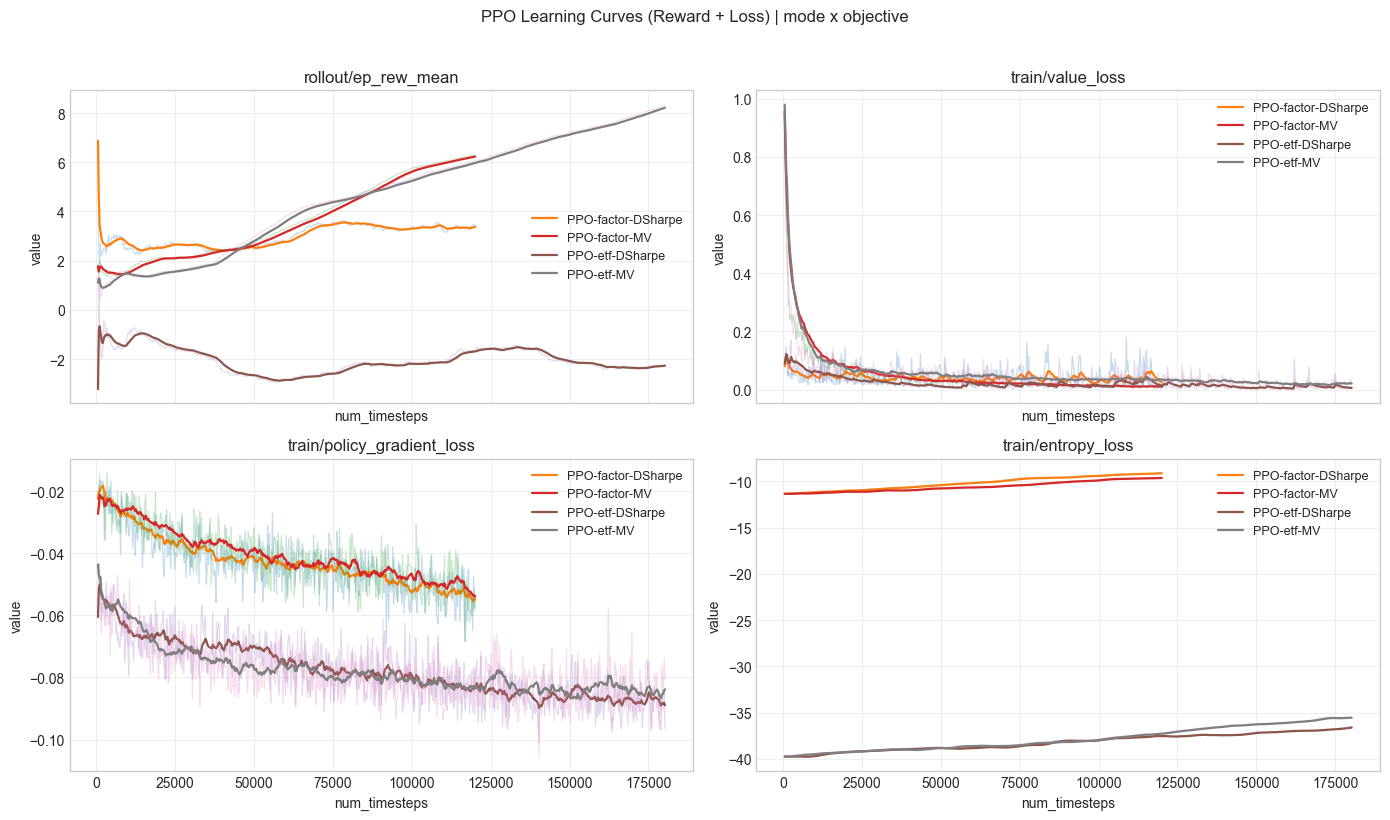

In [16]:
def plot_learning_curves(ppo_results, ppo_order, config):
    lc_cfg = config['rl'].get('learning_curve', {})
    if not bool(lc_cfg.get('enable', True)):
        print('Learning curve plotting is disabled by CONFIG.')
        return

    metrics = list(lc_cfg.get('metrics', [
        'rollout/ep_rew_mean',
        'train/value_loss',
        'train/policy_gradient_loss',
        'train/entropy_loss',
    ]))
    if len(metrics) == 0:
        print('No learning-curve metrics configured.')
        return

    smooth_span = max(1, int(lc_cfg.get('smooth_span', 20)))
    metric_plot_list = metrics[:4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.flatten()

    for ax_i, ax in enumerate(axes):
        if ax_i >= len(metric_plot_list):
            ax.axis('off')
            continue

        metric = metric_plot_list[ax_i]
        has_any_series = False

        for key in ppo_order:
            info = ppo_results[key]
            label = info['label']
            train_log = info.get('train_log', pd.DataFrame())

            if len(train_log) == 0 or metric not in train_log.columns or 'num_timesteps' not in train_log.columns:
                continue

            x = pd.to_numeric(train_log['num_timesteps'], errors='coerce')
            y = pd.to_numeric(train_log[metric], errors='coerce')

            tmp = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()
            if len(tmp) == 0:
                continue

            has_any_series = True
            ax.plot(tmp['x'], tmp['y'], linewidth=0.9, alpha=0.25)
            smooth_y = tmp['y'].ewm(span=smooth_span, min_periods=1).mean()
            ax.plot(tmp['x'], smooth_y, linewidth=1.6, label=label)

        ax.set_title(metric)
        ax.set_xlabel('num_timesteps')
        ax.set_ylabel('value')
        ax.grid(True, alpha=0.3)
        if has_any_series:
            ax.legend(fontsize=9)
        else:
            ax.text(0.5, 0.5, 'metric unavailable', transform=ax.transAxes, ha='center', va='center', fontsize=10)

    fig.suptitle('PPO Learning Curves (Reward + Loss) | mode x objective', y=1.02)
    plt.tight_layout()
    plt.show()


plot_learning_curves(ppo_results=ppo_results, ppo_order=ppo_order, config=CONFIG)


Common test window: 2021-01-01 -> 2026-02-27 (270 periods)
Performance metrics on common test window:


,CAGR,Vol,Sharpe,MDD,Turnover,Hit
PPO-factor-DSharpe,0.0202,0.2333,0.2020,-0.4728,0.1042,0.5074
PPO-factor-MV,0.0010,0.2195,0.1142,-0.4591,0.1334,0.5000
PPO-etf-DSharpe,0.1383,0.2550,0.6361,-0.4673,0.0925,0.5222
PPO-etf-MV,0.1191,0.2733,0.5487,-0.5178,0.1032,0.5185
S2-L,0.0626,0.2234,0.3837,-0.3347,0.1248,0.5111
S2-R,0.1155,0.2589,0.5516,-0.3960,0.1053,0.5259
EQW,0.0293,0.2206,0.2412,-0.4205,0.0026,0.5074


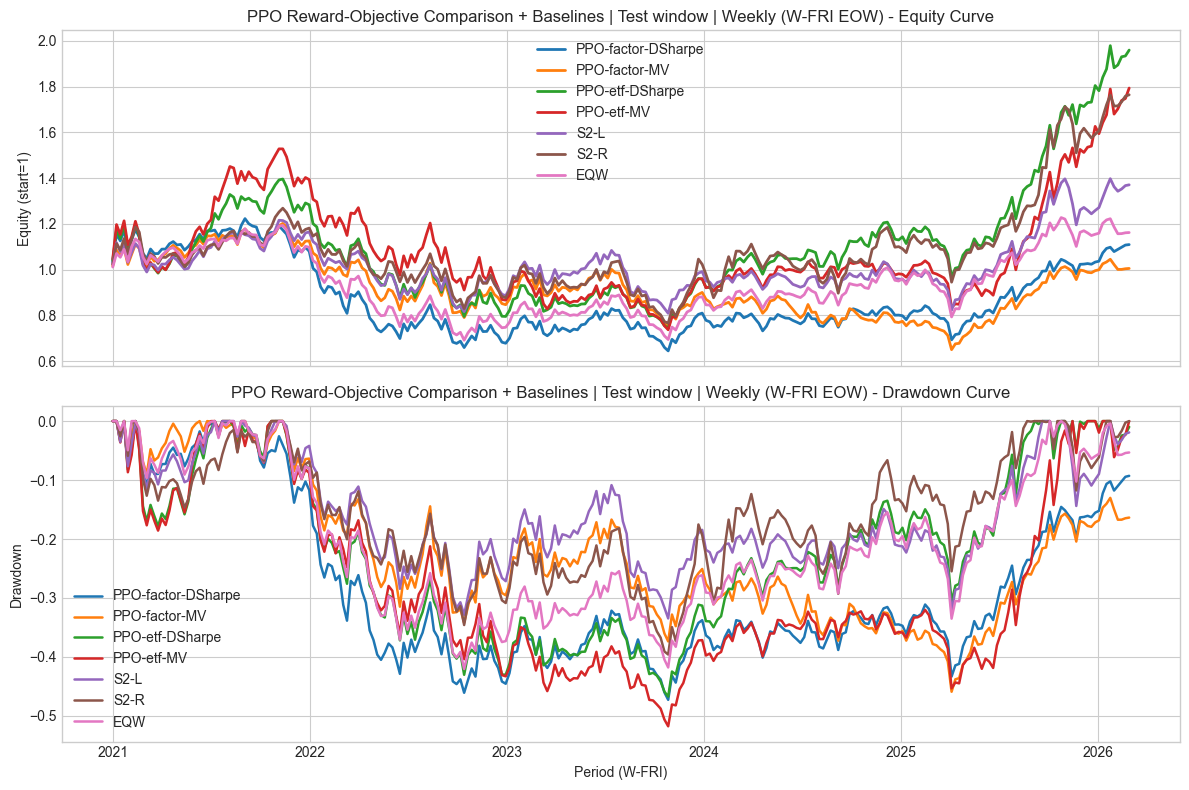

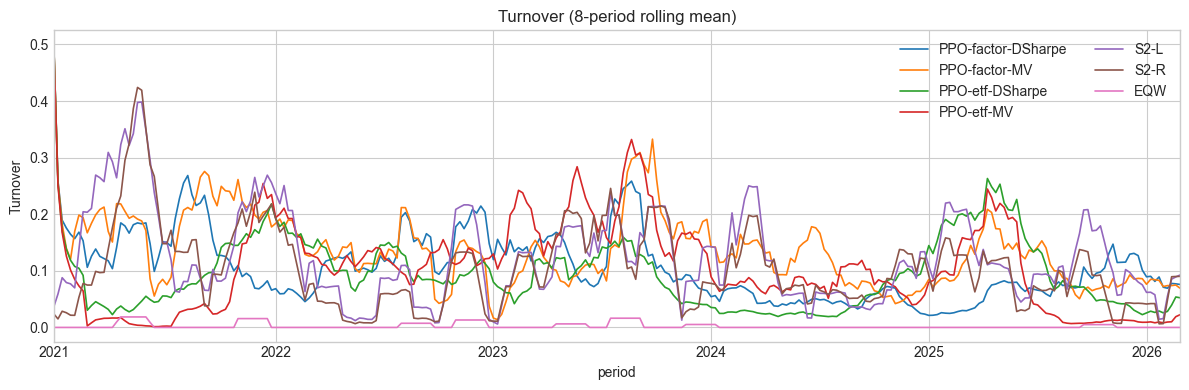

In [17]:
# ベースラインはテスト期間(適用リターン基準)で切り出し
split_date = pd.Timestamp(CONFIG['rl']['split_date'])

net_s2l_test = net_s2l.loc[net_s2l.index >= split_date]
turn_s2l_test = turnover_s2l.reindex(net_s2l_test.index)

net_s2r_test = net_s2r.loc[net_s2r.index >= split_date]
turn_s2r_test = turnover_s2r.reindex(net_s2r_test.index)

eqw_net_test = eqw_net.loc[eqw_net.index >= split_date]
eqw_turn_test = eqw_turnover.reindex(eqw_net_test.index)

ppo_series_map = {ppo_results[k]['label']: ppo_results[k]['net'] for k in ppo_order}
ppo_turn_map = {ppo_results[k]['label']: ppo_results[k]['turnover'] for k in ppo_order}

if len(ppo_series_map) != 4:
    raise ValueError(f'Expected 4 PPO variants, got={len(ppo_series_map)}')

all_idx_list = list(ppo_series_map.values()) + [net_s2l_test, net_s2r_test, eqw_net_test]
common_idx = all_idx_list[0].index
for s in all_idx_list[1:]:
    common_idx = common_idx.intersection(s.index)

if len(common_idx) == 0:
    raise ValueError('No common test window among PPO variants and baselines.')

common_start = common_idx.min()
common_end = common_idx.max()
print(f'Common test window: {common_start.date()} -> {common_end.date()} ({len(common_idx)} periods)')

series_map = {k: v.reindex(common_idx) for k, v in ppo_series_map.items()}
series_map.update({
    'S2-L': net_s2l_test.reindex(common_idx),
    'S2-R': net_s2r_test.reindex(common_idx),
    'EQW': eqw_net_test.reindex(common_idx),
})

turn_map = {k: v.reindex(common_idx) for k, v in ppo_turn_map.items()}
turn_map.update({
    'S2-L': turn_s2l_test.reindex(common_idx),
    'S2-R': turn_s2r_test.reindex(common_idx),
    'EQW': eqw_turn_test.reindex(common_idx),
})

equity_map = {k: (1.0 + v).cumprod() for k, v in series_map.items()}
dd_map = {k: calc_drawdown(v) for k, v in equity_map.items()}

metrics_all = pd.DataFrame({
    k: calc_metrics(series_map[k], turn_map[k], RUNTIME['periods_per_year'])
    for k in series_map
}).T

print('Performance metrics on common test window:')
display(metrics_all)

assert np.isfinite(metrics_all[['CAGR', 'Vol', 'Sharpe', 'MDD', 'Turnover', 'Hit']].values).all(), 'Metrics contain NaN/inf.'

plot_equity_dd(
    equity_map=equity_map,
    dd_map=dd_map,
    title_prefix=f"PPO Reward-Objective Comparison + Baselines | Test window | {RUNTIME['frequency_label']}"
)

fig, ax = plt.subplots(figsize=(12, 4))
for k, v in turn_map.items():
    v.rolling(8, min_periods=1).mean().plot(ax=ax, label=k, linewidth=1.2)
ax.set_title('Turnover (8-period rolling mean)')
ax.set_ylabel('Turnover')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


## 17) PPO診断（リーク・制約・コスト整合・行動統計）

Learning-log checks passed.
VIX load check passed.
Observation dimension check passed.
History reset/step check passed.
Reward formula/stability checks passed.
Weight constraints check passed (all PPO variants).
Cost consistency passed: PPO-factor-DSharpe max_diff=6.939e-18
Cost consistency passed: PPO-factor-MV max_diff=6.939e-18
Cost consistency passed: PPO-etf-DSharpe max_diff=1.388e-17
Cost consistency passed: PPO-etf-MV max_diff=1.388e-17
Train/Test split consistency passed.
Macro timing check passed.
Leak check passed for PPO variants + baselines (including history lag checks).


,strategy,decision_period,max_signal_data_period,applied_return_period
0,PPO-factor-DSharpe,2020-12-25,2020-12-18,2021-01-01
1,PPO-factor-DSharpe,2021-01-01,2020-12-25,2021-01-08
2,PPO-factor-DSharpe,2021-01-08,2021-01-01,2021-01-15
3,PPO-factor-DSharpe,2021-01-15,2021-01-08,2021-01-22
4,PPO-factor-DSharpe,2021-01-22,2021-01-15,2021-01-29
5,PPO-factor-DSharpe,2021-01-29,2021-01-22,2021-02-05
6,PPO-factor-DSharpe,2021-02-05,2021-01-29,2021-02-12
7,PPO-factor-DSharpe,2021-02-12,2021-02-05,2021-02-19
8,PPO-factor-DSharpe,2021-02-19,2021-02-12,2021-02-26
9,PPO-factor-DSharpe,2021-02-26,2021-02-19,2021-03-05


PPO action/reward diagnostics:


,mode,reward_objective,action_l2_mean,action_l2_std,reward_raw_mean,reward_norm_mean,reward_mean,avg_turnover,net_periods
label,,,,,,,,,
PPO-factor-DSharpe,factor,differential_sharpe,3.5410,0.6453,1.1388,"12,093.1035",-0.0148,0.1042,270
PPO-factor-MV,factor,mean_variance,5.0448,0.8853,-0.0037,0.6565,-0.0021,0.1334,270
PPO-etf-DSharpe,etf,differential_sharpe,7.9494,1.4370,1.3989,"14,474.2480",-0.0150,0.0925,270
PPO-etf-MV,etf,mean_variance,8.2264,1.2308,-0.0032,1.7507,0.0131,0.1032,270


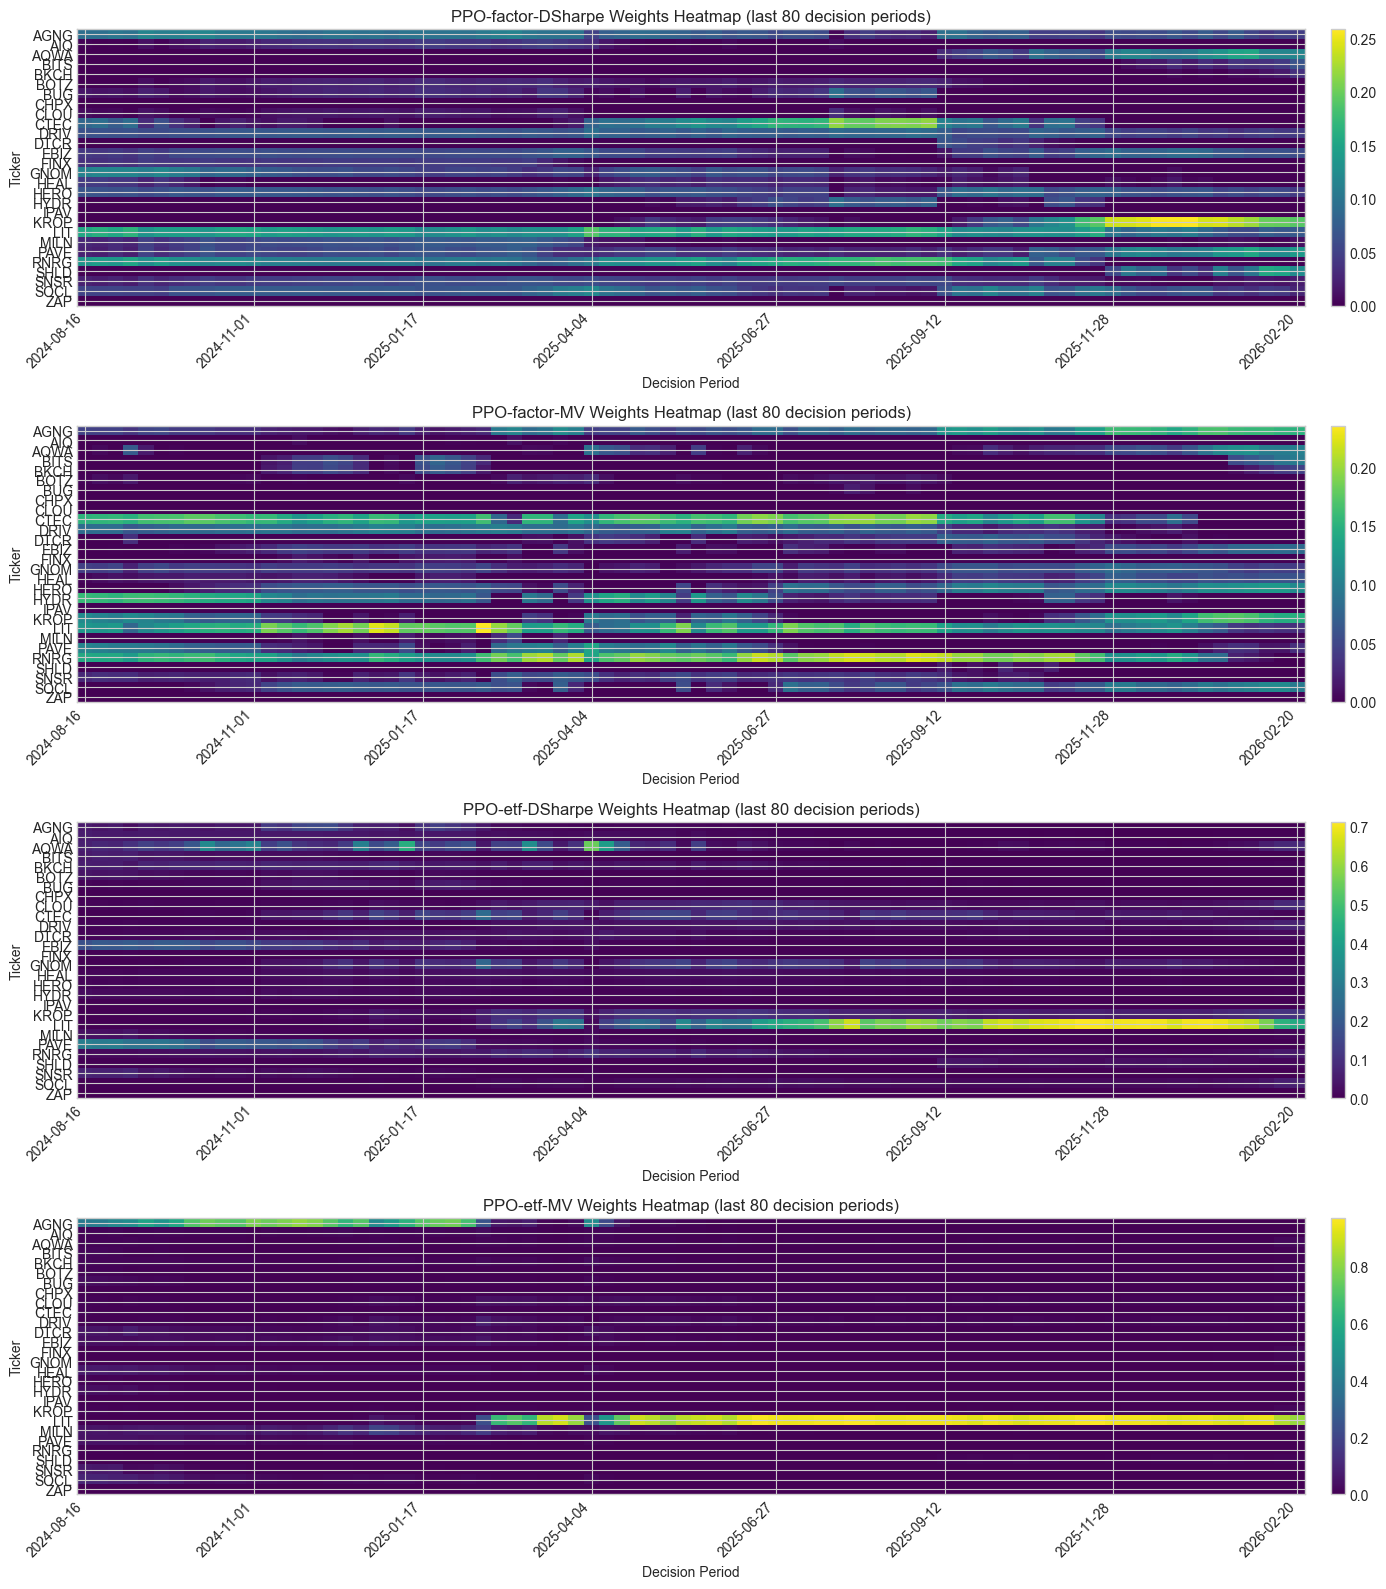

In [18]:
def assert_long_only_weights(weights_df, name='strategy', tol=1e-8):
    if weights_df.empty:
        raise AssertionError(f'{name}: empty weights')

    min_w = float(weights_df.min().min())
    if min_w < -tol:
        raise AssertionError(f'{name}: negative weight detected (min={min_w})')

    sums = weights_df.sum(axis=1)
    valid = ((np.abs(sums - 1.0) <= 1e-6) | (np.abs(sums) <= 1e-6))
    if not bool(valid.all()):
        bad = sums.loc[~valid].head(3)
        raise AssertionError(f'{name}: weight sum must be 1 or 0. bad sample={bad.to_dict()}')


def check_env_vs_backtest(step_df, net_series, name='strategy', tol=1e-10):
    if len(step_df) == 0:
        raise AssertionError(f'{name}: empty step_df')

    env_net = step_df.groupby('applied_period')['net'].sum().sort_index().rename('env_net')
    bt_net = net_series.sort_index().rename('bt_net')
    chk = pd.concat([env_net, bt_net], axis=1).dropna()
    if len(chk) == 0:
        raise AssertionError(f'{name}: no overlapping periods for env-vs-bt check')

    diff = (chk['env_net'] - chk['bt_net']).abs()
    max_diff = float(diff.max())
    assert max_diff <= tol, f'{name}: env vs backtest mismatch (max_diff={max_diff})'
    return max_diff



# -1) 学習ログ健全性検証
lc_cfg = CONFIG['rl'].get('learning_curve', {})
min_points_warn = int(lc_cfg.get('min_points_warn', 10))
smooth_span = max(1, int(lc_cfg.get('smooth_span', 20)))
required_curve_metrics = ['rollout/ep_rew_mean', 'train/value_loss']

for key in ppo_order:
    info = ppo_results[key]
    label = info['label']
    train_log = info.get('train_log', pd.DataFrame())

    assert len(train_log) > 0, f'{label}: empty train_log'
    assert 'num_timesteps' in train_log.columns, f'{label}: missing num_timesteps in train_log'

    ts = pd.to_numeric(train_log['num_timesteps'], errors='coerce')
    assert ts.notna().all(), f'{label}: num_timesteps has NaN'
    assert bool(pd.Series(ts).is_monotonic_increasing), f'{label}: num_timesteps must be monotonic increasing'

    if len(train_log) < min_points_warn:
        print(f'Warning: {label} train_log points={len(train_log)} < min_points_warn={min_points_warn}')

    for metric in required_curve_metrics:
        assert metric in train_log.columns, f'{label}: missing learning metric {metric}'
        y = pd.to_numeric(train_log[metric], errors='coerce')
        finite = np.isfinite(y.values)
        assert bool(finite.any()), f'{label}: no finite values in {metric}'

        y_clean = pd.Series(y).replace([np.inf, -np.inf], np.nan).dropna()
        if len(y_clean) > 0:
            y_smooth = y_clean.ewm(span=smooth_span, min_periods=1).mean()
            assert np.isfinite(y_smooth.values).all(), f'{label}: non-finite smoothed values in {metric}'

print('Learning-log checks passed.')

# 0) VIXロード検証
vix_cfg = CONFIG['rl']['macro']
if bool(vix_cfg.get('enable_vix', False)):
    assert len(vix_features) > 0, 'VIX feature is enabled but vix_features is empty.'
    assert vix_features.index.is_monotonic_increasing, 'VIX index must be monotonic increasing.'
    assert pd.api.types.is_numeric_dtype(vix_features['vix_level']), 'VIX level must be numeric.'
    print('VIX load check passed.')

# 1) 観測次元検証
for key in ppo_order:
    info = ppo_results[key]
    env = info['test_env_obj']
    expected_dim = env.obs_feature_dim
    if env.include_action_history:
        expected_dim += env.history_len * len(env.tickers)
    expected_dim += env.history_len * len(env.agent_state_fields)
    assert env.obs_dim == expected_dim, f"{info['label']}: obs_dim mismatch env={env.obs_dim}, expected={expected_dim}"
    assert env.observation_space.shape[0] == expected_dim, f"{info['label']}: observation_space shape mismatch"

print('Observation dimension check passed.')

# 2) reset/step履歴更新検証
for key in ppo_order:
    info = ppo_results[key]
    env = info['test_env_obj']
    obs0, _ = env.reset(seed=int(CONFIG['rl']['seed']))

    action_hist_len = env.history_len * len(env.tickers) if env.include_action_history else 0
    state_hist_len = env.history_len * len(env.agent_state_fields)

    if action_hist_len > 0:
        action_hist0 = obs0[env.obs_feature_dim : env.obs_feature_dim + action_hist_len]
        assert np.allclose(action_hist0, 0.0), f"{info['label']}: action history must be zero at reset."

    state_hist0 = obs0[-state_hist_len:]
    assert np.allclose(state_hist0, 0.0), f"{info['label']}: state history must be zero at reset."

    test_action = np.zeros(env.action_space.shape, dtype=np.float32)
    obs1, reward1, terminated1, truncated1, step_info = env.step(test_action)

    if not (terminated1 or truncated1):
        if action_hist_len > 0:
            action_hist1 = obs1[env.obs_feature_dim : env.obs_feature_dim + action_hist_len].reshape(env.history_len, len(env.tickers))
            expected_last_action = step_info['weights'].reindex(env.tickers).fillna(0.0).values.astype(np.float32)
            assert np.allclose(action_hist1[-1], expected_last_action), f"{info['label']}: latest action history mismatch."

        state_hist1 = obs1[-state_hist_len:].reshape(env.history_len, len(env.agent_state_fields))
        field_to_idx = {f: i for i, f in enumerate(env.agent_state_fields)}
        assert abs(float(state_hist1[-1, field_to_idx['net']]) - float(step_info['net'])) < 1e-8, f"{info['label']}: latest net history mismatch."
        assert abs(float(state_hist1[-1, field_to_idx['turnover']]) - float(step_info['turnover'])) < 1e-8, f"{info['label']}: latest turnover history mismatch."

print('History reset/step check passed.')

# 3) 報酬健全性検証
for key in ppo_order:
    info = ppo_results[key]
    steps = info['steps']
    assert len(steps) > 0, f"{info['label']}: empty steps"
    assert np.isfinite(steps[['reward', 'reward_raw', 'reward_norm', 'risk_var_prev', 'risk_sigma_prev']].values).all(), f"{info['label']}: non-finite reward/risk detected"
    assert (steps['risk_var_prev'] >= -1e-12).all(), f"{info['label']}: negative risk variance detected"

    if bool(CONFIG['rl']['reward_stabilizer'].get('tanh_clip', True)):
        assert (steps['reward'].abs() <= 1.000001).all(), f"{info['label']}: reward out of tanh range"

    expected_obj = info['reward_objective']
    assert set(steps['reward_objective'].dropna().unique()) == {expected_obj}, f"{info['label']}: objective tag mismatch"

print('Reward formula/stability checks passed.')

# 4) 重み制約
for key in ppo_order:
    info = ppo_results[key]
    assert_long_only_weights(info['weights'], name=info['label'])
print('Weight constraints check passed (all PPO variants).')

# 5) コスト整合（env計算とrun_backtest再計算）
for key in ppo_order:
    info = ppo_results[key]
    max_diff = check_env_vs_backtest(
        step_df=info['steps'],
        net_series=info['net'],
        name=info['label'],
    )
    print(f"Cost consistency passed: {info['label']} max_diff={max_diff:.3e}")

# 6) 分割整合
for key in ppo_order:
    info = ppo_results[key]
    st = info['split_tbl']
    train_applied = st.loc[st['applied_period'] < split_date, 'applied_period']
    test_applied = st.loc[st['applied_period'] >= split_date, 'applied_period']

    assert len(set(train_applied).intersection(set(test_applied))) == 0, f"{info['label']}: applied period overlap"
    assert (train_applied < split_date).all(), f"{info['label']}: train applied period violation"
    assert (test_applied >= split_date).all(), f"{info['label']}: test applied period violation"

print('Train/Test split consistency passed.')

# 7) マクロ時点整合（VIX特徴はtまでのみ）
macro_cols = [c for c in rl_features.columns if c.startswith('vix_')]
if len(macro_cols) > 0:
    sampled_idx = rl_features.index[::max(1, len(rl_features) // 20)]
    for t in sampled_idx:
        assert t in rl_features.index, f'rl_features missing decision date: {t}'
        assert (vix_features.index <= t).any(), f'No VIX history available up to decision date {t}'

    print('Macro timing check passed.')

# 8) リーク検証（既存関数を再利用）
leak_rows = []
for key in ppo_order:
    info = ppo_results[key]
    tbl = make_leak_check_table(info['net'], ret_p.index, name=info['label'])
    leak_rows.append(tbl)

for name, s in {
    'S2-L': net_s2l_test,
    'S2-R': net_s2r_test,
    'EQW': eqw_net_test,
}.items():
    leak_rows.append(make_leak_check_table(s, ret_p.index, name=name))

leak_tbl_all = pd.concat(leak_rows, axis=0).reset_index(drop=True)
valid_leak = leak_tbl_all.dropna(subset=['max_signal_data_period', 'decision_period', 'applied_return_period'])

assert (valid_leak['max_signal_data_period'] <= valid_leak['decision_period']).all(), 'Leak check failed: future info in signal.'
assert (valid_leak['decision_period'] < valid_leak['applied_return_period']).all(), 'Leak check failed: not applied to t+1.'

for key in ppo_order:
    info = ppo_results[key]
    steps_mode = info['steps'].copy()
    hist_valid = steps_mode.dropna(subset=['history_latest_period'])
    assert (hist_valid['history_latest_period'] <= hist_valid['decision_period']).all(), f"{info['label']}: history leakage detected."

print('Leak check passed for PPO variants + baselines (including history lag checks).')
display(valid_leak.head(14))

# 9) 行動・報酬統計
action_stats = []
for key in ppo_order:
    info = ppo_results[key]
    steps = info['steps']
    avg_turn = float(info['turnover'].mean()) if len(info['turnover']) > 0 else np.nan

    action_stats.append({
        'label': info['label'],
        'mode': info['mode'],
        'reward_objective': info['reward_objective'],
        'action_l2_mean': float(steps['action_l2'].mean()) if len(steps) > 0 else np.nan,
        'action_l2_std': float(steps['action_l2'].std(ddof=0)) if len(steps) > 0 else np.nan,
        'reward_raw_mean': float(steps['reward_raw'].mean()) if len(steps) > 0 else np.nan,
        'reward_norm_mean': float(steps['reward_norm'].mean()) if len(steps) > 0 else np.nan,
        'reward_mean': float(steps['reward'].mean()) if len(steps) > 0 else np.nan,
        'avg_turnover': avg_turn,
        'net_periods': int(len(info['net'])),
    })

action_stats_df = pd.DataFrame(action_stats).set_index('label')
print('PPO action/reward diagnostics:')
display(action_stats_df)

# 10) 重みヒートマップ（4 PPO系列）
n = len(ppo_order)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

for i, key in enumerate(ppo_order):
    info = ppo_results[key]
    w = info['weights'].copy().tail(min(len(info['weights']), 80))

    if len(w) == 0:
        axes[i].text(0.5, 0.5, 'No weights', ha='center', va='center')
        axes[i].set_axis_off()
        continue

    mat = w.T.values
    im = axes[i].imshow(mat, aspect='auto', cmap='viridis', interpolation='nearest')

    axes[i].set_title(f"{info['label']} Weights Heatmap (last {len(w)} decision periods)")
    axes[i].set_ylabel('Ticker')
    axes[i].set_yticks(np.arange(len(w.columns)))
    axes[i].set_yticklabels(w.columns)

    xticks = np.linspace(0, len(w.index) - 1, num=min(8, len(w.index)), dtype=int)
    axes[i].set_xticks(xticks)
    axes[i].set_xticklabels([w.index[j].date().isoformat() for j in xticks], rotation=45, ha='right')
    axes[i].set_xlabel('Decision Period')

    fig.colorbar(im, ax=axes[i], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()
